# **Exploratory Data Analysis (EDA)** - Bank Fraud Analysis

### Overview

This notebook presents the Exploratory Data Analysis (EDA) of the cleaned Bank Fraud dataset. The objective of this analysis is to understand the underlying characteristics of the data, identify meaningful patterns, uncover relationships between variables, and derive insights related to fraudulent transactions.

The analysis includes statistical summaries, univariate and bivariate analyses, correlation analysis, and a variety of visualizations to better understand customer behavior, transaction characteristics, and fraud trends. The findings from this notebook will also serve as the foundation for the interactive Streamlit dashboard developed later in the project.

### Objectives

The primary objectives of this notebook are:
- Understand the overall structure and characteristics of the cleaned dataset.
- Perform descriptive statistical analysis.
- Explore the distribution of numerical and categorical features.
- Analyze fraudulent and non-fraudulent transactions.
- Identify relationships between different variables.
- Discover patterns and trends that may indicate fraudulent activities.
- Generate insights to support the development of an interactive dashboard.

## Import Required Libraries
The following libraries are imported to perform data manipulation, statistical analysis, and data visualization throughout this notebook.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Load the Cleaned Dataset

The cleaned dataset generated during the data preprocessing stage is loaded into a Pandas DataFrame. This dataset will be used for all subsequent exploratory analyses.

In [3]:
df = pd.read_csv("../data/processed/bank_fraud_cleaned.csv")

## Dataset Overview

Before performing detailed analysis, it is important to examine the overall structure of the dataset. This includes checking the number of observations, available features, data types, and a preview of the records to gain a better understanding of the data.

In [4]:
df.head()

,transaction_id,customer_id,hour_of_day,is_weekend,is_night_transaction,country,city,merchant_category,payment_method,device_type,...,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud,fraud_type,transaction_datetime
0,TXN0000000001,CUST00121959,21,0,0,USA,London,Grocery,Bank Transfer,POS Terminal,...,157,23,52.7,10.20,0,0,0,0,No Fraud,2023-08-17 21:13:00
1,TXN0000000002,CUST00146868,5,0,1,UK,New York,Healthcare,Cheque,Desktop,...,153,23,0.9,12.47,0,0,0,0,No Fraud,2024-02-06 05:16:00
2,TXN0000000003,CUST00131933,12,0,0,Canada,Delhi,Grocery,Crypto,Mobile,...,161,20,9.2,0.08,0,1,0,0,No Fraud,2024-06-28 12:15:00
3,TXN0000000004,CUST00103695,2,0,1,France,Tokyo,Utilities,Debit Card,Mobile,...,160,25,14.8,17.94,1,0,1,1,Synthetic Identity,2023-03-16 02:53:00
4,TXN0000000005,CUST00119880,12,0,0,Canada,Melbourne,Clothing,Debit Card,Desktop,...,134,18,38.9,2.16,0,0,0,0,No Fraud,2024-07-12 12:39:00


In [5]:
df.shape

(1000000, 25)

In [6]:
df.columns

Index(['transaction_id', 'customer_id', 'hour_of_day', 'is_weekend',
       'is_night_transaction', 'country', 'city', 'merchant_category',
       'payment_method', 'device_type', 'customer_age', 'credit_score',
       'account_age_years', 'account_balance', 'transaction_amount',
       'num_prev_transactions', 'transaction_freq_monthly',
       'distance_from_home_km', 'time_since_last_txn_hrs', 'is_international',
       'failed_attempts', 'pin_changed_recently', 'is_fraud', 'fraud_type',
       'transaction_datetime'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 25 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   transaction_id            1000000 non-null  str    
 1   customer_id               1000000 non-null  str    
 2   hour_of_day               1000000 non-null  int64  
 3   is_weekend                1000000 non-null  int64  
 4   is_night_transaction      1000000 non-null  int64  
 5   country                   1000000 non-null  str    
 6   city                      1000000 non-null  str    
 7   merchant_category         1000000 non-null  str    
 8   payment_method            1000000 non-null  str    
 9   device_type               1000000 non-null  str    
 10  customer_age              1000000 non-null  int64  
 11  credit_score              1000000 non-null  int64  
 12  account_age_years         1000000 non-null  float64
 13  account_balance           1000000 non-n

#### Observation

The dataset contains **1,000,000 transaction records** and **25 features** describing customer information, transaction details, and fraud-related attributes.

The dataset consists of numerical, categorical, and binary variables. All columns have appropriate data types, and no missing values are present after the data cleaning process.

## Descriptive Statistics

Descriptive statistics provide a numerical summary of the dataset by calculating measures such as count, mean, standard deviation, minimum, maximum, and quartiles. Examining these statistics helps identify the overall distribution of numerical features and highlights potential anomalies or extreme values that may require further investigation.

In [8]:
df.describe()

,hour_of_day,is_weekend,is_night_transaction,customer_age,credit_score,account_age_years,account_balance,transaction_amount,num_prev_transactions,transaction_freq_monthly,distance_from_home_km,time_since_last_txn_hrs,is_international,failed_attempts,pin_changed_recently,is_fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,11.496978,0.286022,0.375057,41.771678,679.028781,4.987911,16594.25442,204.724665,149.996350,19.999322,20.009890,12.000945,0.149994,0.380072,0.080439,0.055255
std,6.923751,0.451900,0.484138,13.424588,78.828748,4.925949,28171.46068,459.567802,12.244379,4.474045,20.011427,11.999904,0.357066,0.914603,0.271972,0.228477
min,0.000000,0.000000,0.000000,18.000000,300.000000,0.100000,100.00000,1.000000,96.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000,32.000000,625.000000,1.400000,3609.01750,33.400000,142.000000,17.000000,5.800000,3.450000,0.000000,0.000000,0.000000,0.000000
50%,11.000000,0.000000,0.000000,42.000000,680.000000,3.500000,8092.12000,73.120000,150.000000,20.000000,13.900000,8.320000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,1.000000,1.000000,51.000000,734.000000,6.900000,18225.02500,181.450000,158.000000,23.000000,27.700000,16.630000,0.000000,0.000000,0.000000,0.000000
max,23.000000,1.000000,1.000000,85.000000,850.000000,30.000000,500000.00000,46129.600000,213.000000,44.000000,292.100000,154.200000,1.000000,5.000000,1.000000,1.000000


#### Observation

The statistical summary provides an overview of the central tendency and variability of the numerical variables. Differences between the mean, median (50th percentile), and extreme values may indicate skewed distributions or the presence of outliers. These characteristics will be explored further using visualizations in the subsequent sections.

### Numerical Features

The dataset contains the following numerical features, which will be analyzed to understand their distributions, variability, and relationship with fraudulent transactions.

In [9]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
numerical_columns

Index(['hour_of_day', 'is_weekend', 'is_night_transaction', 'customer_age',
       'credit_score', 'account_age_years', 'account_balance',
       'transaction_amount', 'num_prev_transactions',
       'transaction_freq_monthly', 'distance_from_home_km',
       'time_since_last_txn_hrs', 'is_international', 'failed_attempts',
       'pin_changed_recently', 'is_fraud'],
      dtype='str')

### Categorical Features

Categorical features describe qualitative information such as customer location, merchant category, payment method, and fraud type. These variables will be analyzed using frequency distributions and categorical visualizations.

In [10]:
categorical_columns = df.select_dtypes(include=["object"]).columns
categorical_columns

C:\Users\hp\AppData\Local\Temp\ipykernel_14096\1154281218.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


Index(['transaction_id', 'customer_id', 'country', 'city', 'merchant_category',
       'payment_method', 'device_type', 'fraud_type', 'transaction_datetime'],
      dtype='str')

## Univariate Analysis

Univariate analysis focuses on examining one variable at a time to understand its distribution, central tendency, spread, and potential outliers. This analysis provides valuable insights into the characteristics of individual features before exploring relationships between multiple variables.

### FINANCIAL FEATURES

#### Distribution of Transaction Amount

Transaction amount is one of the most important financial variables in the dataset. Analyzing its distribution helps identify common transaction ranges, detect skewness, and reveal unusually large or small transactions that may require further investigation.

##### Analysis Objective
To examine the distribution of transaction amounts, identify potential skewness and outliers, and understand the overall spending patterns within the dataset.

In [11]:
df["transaction_amount"].median()

np.float64(73.12)

In [12]:
df["transaction_amount"].describe()

count    1000000.000000
mean         204.724665
std          459.567802
min            1.000000
25%           33.400000
50%           73.120000
75%          181.450000
max        46129.600000
Name: transaction_amount, dtype: float64

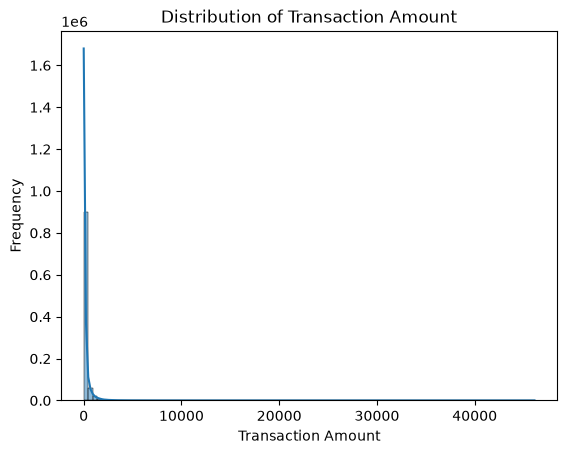

In [13]:
sns.histplot(
    df["transaction_amount"],
    bins=100,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

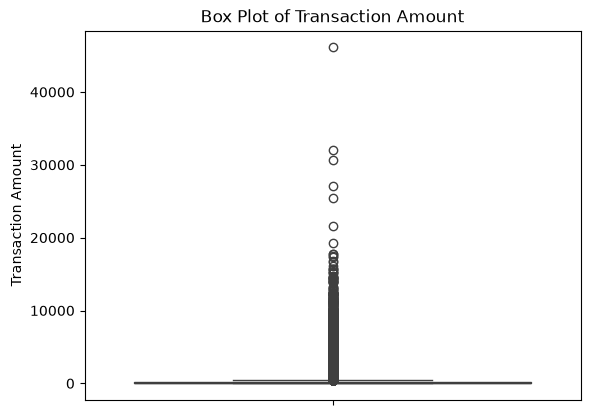

In [14]:
sns.boxplot(
    df["transaction_amount"]
)

plt.ylabel("Transaction Amount")
plt.title("Box Plot of Transaction Amount")

plt.show()

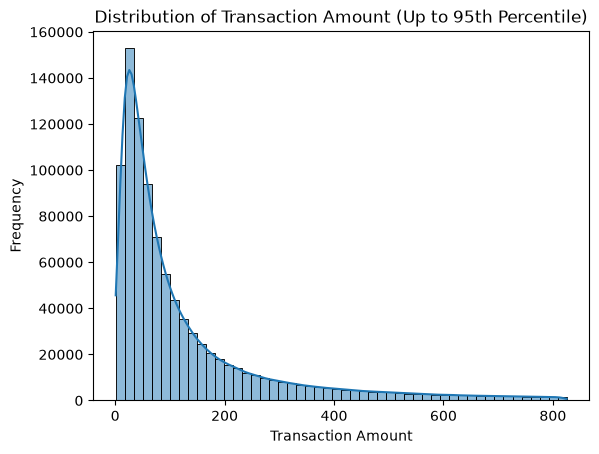

In [15]:
limit = df["transaction_amount"].quantile(0.95)

sns.histplot(
    df[df["transaction_amount"] <= limit]["transaction_amount"],
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount (Up to 95th Percentile)")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

##### Observation
- Transaction amounts are highly right-skewed.
- Most transactions are concentrated within the lower transaction range.
- A small number of transactions have exceptionally high values, resulting in numerous outliers.
- The mean transaction amount (204.79) is significantly higher than the median (73.12), indicating the influence of these high-value transactions.

#### Distribution of Account Balance

Account Balance is another financial variable in the dataset. Analyzing its distribution helps identify common balance ranges, detect skewness, and reveal unusually large or small balance amounts that may require further investigation.

##### Analysis Objective
To examine the distribution of account balance amounts, identify potential skewness and outliers, and understand the overall patterns within the dataset.

In [16]:
df["account_balance"].median()

np.float64(8092.12)

In [17]:
df["account_balance"].describe()

count    1000000.00000
mean       16594.25442
std        28171.46068
min          100.00000
25%         3609.01750
50%         8092.12000
75%        18225.02500
max       500000.00000
Name: account_balance, dtype: float64

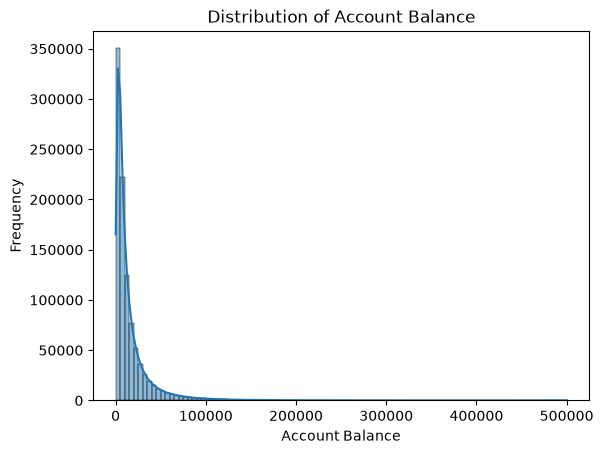

In [18]:
sns.histplot(
    df["account_balance"],
    bins = 100,
    kde = True
)

plt.title("Distribution of Account Balance")
plt.xlabel("Account Balance")
plt.ylabel("Frequency")

plt.show()

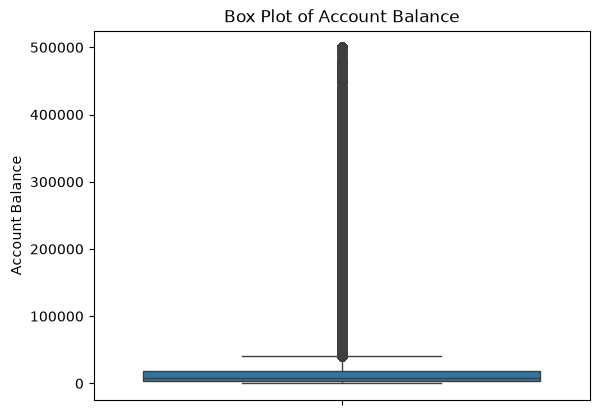

In [19]:
sns.boxplot(
    df["account_balance"]
)

plt.ylabel("Account Balance")
plt.title("Box Plot of Account Balance")

plt.show()

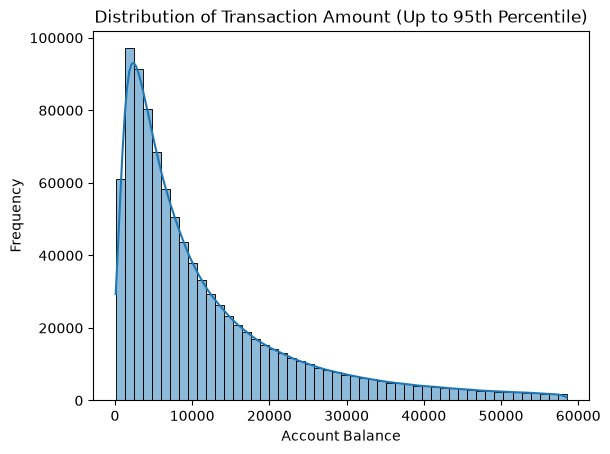

In [20]:
limit = df["account_balance"].quantile(0.95)

sns.histplot(
    df[df["account_balance"] <= limit]["account_balance"],
    bins = 50,
    kde = True
)

plt.xlabel("Account Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Transaction Amount (Up to 95th Percentile)")

plt.show()

##### Observation
- Customer account balances exhibit a positively skewed distribution.
- Most customers maintain relatively modest account balances, while a smaller proportion hold significantly larger balances.
- The mean account balance (16594.25) is considerably higher than the median (8092.12), indicating the influence of high-balance accounts.
- The wide range of values suggests substantial variability in customer account balances.

### CUSTOMER FEATURES

#### Distribution of Customer Age

Customer age is an important demographic feature that provides insight into the composition of the customer base. Analyzing its distribution helps understand the age groups represented in the dataset and identify any unusual patterns or extreme values.

##### Analysis Objective

To examine the distribution of customer ages, identify the predominant age groups, detect potential outliers, and gain an understanding of the overall demographic profile of the customers.

In [21]:
df["customer_age"].median()

np.float64(42.0)

In [22]:
df["customer_age"].describe()

count    1000000.000000
mean          41.771678
std           13.424588
min           18.000000
25%           32.000000
50%           42.000000
75%           51.000000
max           85.000000
Name: customer_age, dtype: float64

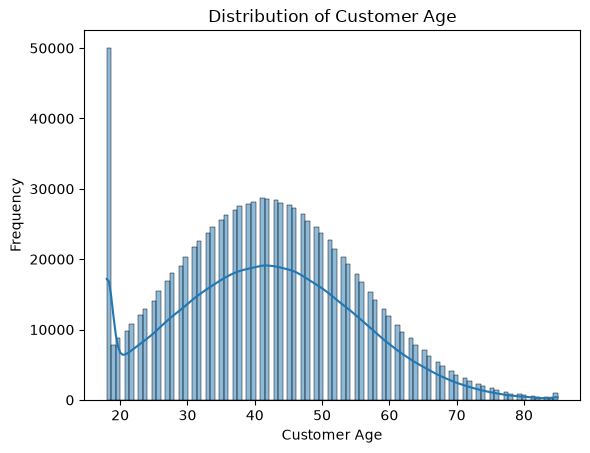

In [23]:
sns.histplot(
    df["customer_age"],
    bins = 100,
    kde = True
)

plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.title("Distribution of Customer Age")

plt.show()

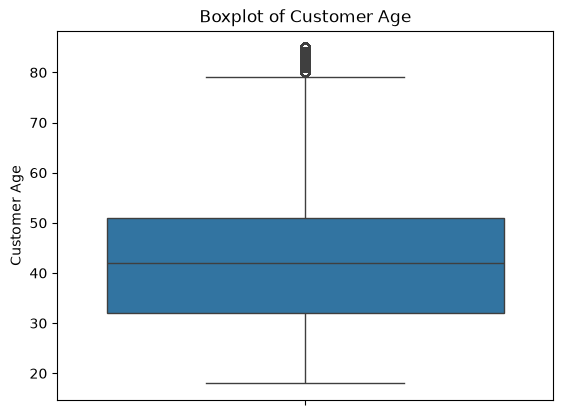

In [24]:
sns.boxplot(
    df["customer_age"]
)

plt.ylabel("Customer Age")
plt.title("Boxplot of Customer Age")

plt.show()

##### Observation

- Customer ages range from **18 to 85 years**, representing an adult customer population.
- The mean age (41.77 years) is nearly identical to the median (42 years), suggesting that the distribution is approximately symmetric.
- The age distribution exhibits moderate variability, with half of the customers falling between **32 and 51 years**.
- No obvious anomalies or unrealistic age values are observed in the dataset.

#### Distribution of Credit Score

Credit score is an important financial indicator that reflects a customer's creditworthiness. Analyzing its distribution helps understand the overall credit profile of customers, identify common credit score ranges, and detect any unusual or extreme values that may warrant further investigation.

##### Analysis Objective

To examine the distribution of customer credit scores, identify the predominant credit score ranges, detect potential outliers, and gain insights into the overall creditworthiness of the customer population.

In [25]:
df["credit_score"].median()

np.float64(680.0)

In [26]:
df["credit_score"].describe()

count    1000000.000000
mean         679.028781
std           78.828748
min          300.000000
25%          625.000000
50%          680.000000
75%          734.000000
max          850.000000
Name: credit_score, dtype: float64

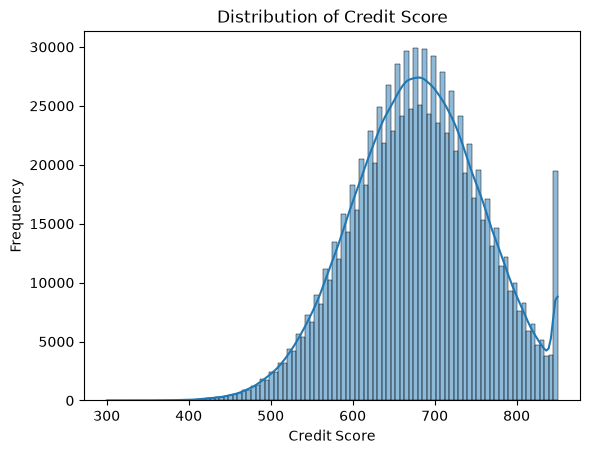

In [27]:
sns.histplot(
    df["credit_score"],
    bins = 100,
    kde = True
)

plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.title("Distribution of Credit Score")

plt.show()

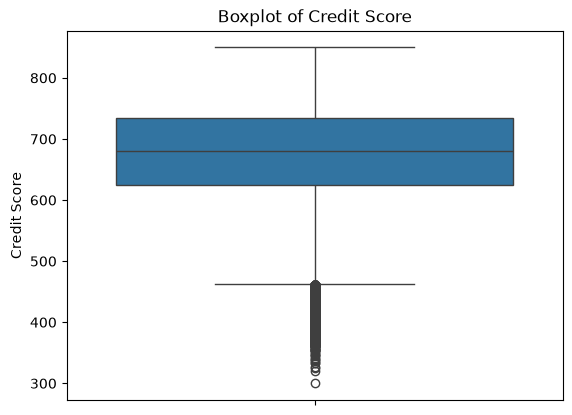

In [28]:
sns.boxplot(
    df["credit_score"]
)

plt.ylabel("Credit Score")
plt.title("Boxplot of Credit Score")

plt.show()

##### Observation

- Customer credit scores range from **300 to 850**, covering the full spectrum of creditworthiness.
- The mean credit score (679.03) is nearly identical to the median (680), indicating an approximately symmetric distribution.
- Half of the customers have credit scores between **625 and 734**, suggesting that most customers fall within a moderate to good credit score range.
- No unrealistic or anomalous credit score values are observed in the dataset.

#### Distribution of Account Age

Account age represents the duration for which a customer has maintained their bank account. Analyzing its distribution helps understand the maturity of customer accounts, identify common account age ranges, and detect any unusual or extreme values that may influence transaction behavior or fraud-related patterns.

##### Analysis Objective

To examine the distribution of customer account ages, identify the predominant account age ranges, detect potential outliers, and gain insights into the overall maturity of customer accounts within the dataset.

In [29]:
df["account_age_years"].median()

np.float64(3.5)

In [30]:
df["account_age_years"].describe()

count    1000000.000000
mean           4.987911
std            4.925949
min            0.100000
25%            1.400000
50%            3.500000
75%            6.900000
max           30.000000
Name: account_age_years, dtype: float64

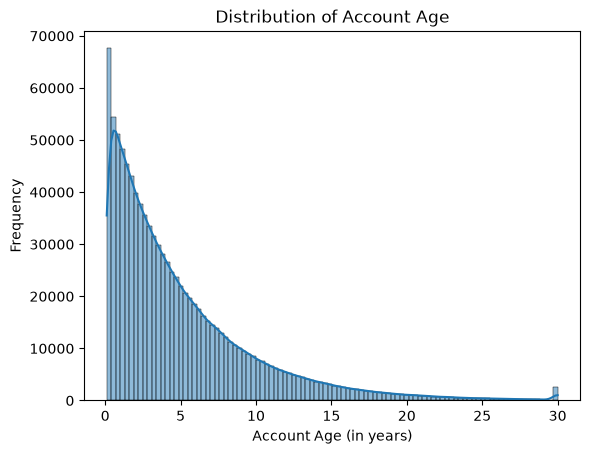

In [31]:
sns.histplot(
    df["account_age_years"],
    bins = 100,
    kde = True
)

plt.xlabel("Account Age (in years)")
plt.ylabel("Frequency")
plt.title("Distribution of Account Age")

plt.show()

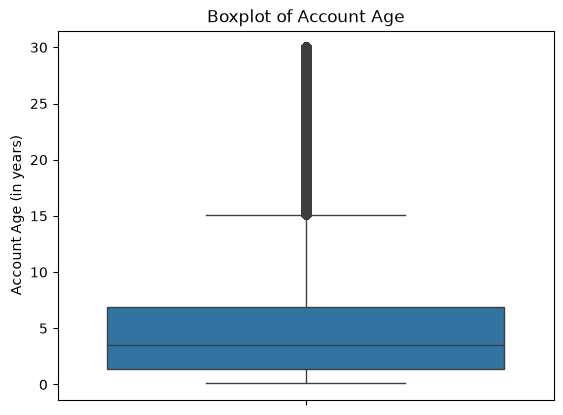

In [32]:
sns.boxplot(
    df["account_age_years"]
)

plt.ylabel("Account Age (in years)")
plt.title("Boxplot of Account Age")

plt.show()

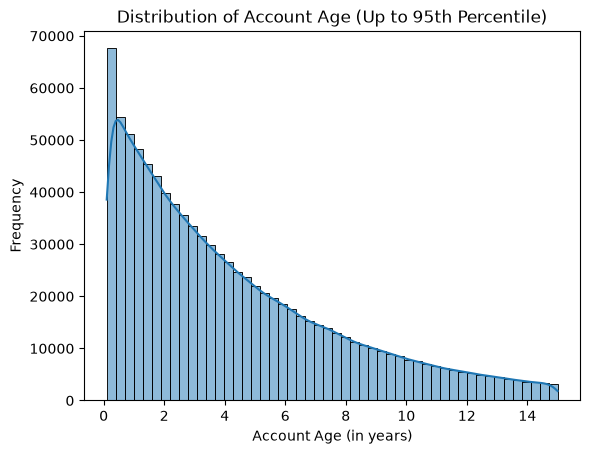

In [33]:
limit = df["account_age_years"].quantile(0.95)

sns.histplot(
    df[df["account_age_years"] <= limit]["account_age_years"],
    bins = 50,
    kde = True
)

plt.xlabel("Account Age (in years)")
plt.ylabel("Frequency")
plt.title("Distribution of Account Age (Up to 95th Percentile)")

plt.show()

##### Observation

- Customer account ages range from **0.1 to 30 years**, indicating a diverse mix of newly opened and long-established accounts.
- The mean account age (4.99 years) is higher than the median (3.5 years), suggesting a moderately right-skewed distribution.
- Half of the customer accounts have been active for **1.4 to 6.9 years**, indicating that most accounts are relatively young to moderately established.
- No unrealistic account age values are observed in the dataset.

### TRANSACTION BEHAVIOUR

#### Distribution of Transaction Hour

The transaction hour represents the time of day at which each transaction occurred. Analyzing its distribution helps identify peak transaction periods, understand customer transaction behavior throughout the day, and detect any unusual temporal patterns that may be relevant for fraud analysis.

##### Analysis Objective

To examine the distribution of transaction hours, identify the periods during which transactions occur most frequently, and gain insights into daily transaction patterns that may support subsequent fraud-related analyses.

In [34]:
df["hour_of_day"].value_counts().sort_index()

hour_of_day
0     41758
1     41643
2     41564
3     41933
4     41811
5     41889
6     41430
7     41649
8     41564
9     41423
10    41895
11    41642
12    41654
13    41683
14    41516
15    41697
16    41133
17    41905
18    41723
19    41831
20    41704
21    41924
22    41608
23    41421
Name: count, dtype: int64

In [35]:
hour_percentage = (
    df["hour_of_day"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

hour_percentage.round(2)

hour_of_day
0     4.18
1     4.16
2     4.16
3     4.19
4     4.18
5     4.19
6     4.14
7     4.16
8     4.16
9     4.14
10    4.19
11    4.16
12    4.17
13    4.17
14    4.15
15    4.17
16    4.11
17    4.19
18    4.17
19    4.18
20    4.17
21    4.19
22    4.16
23    4.14
Name: proportion, dtype: float64

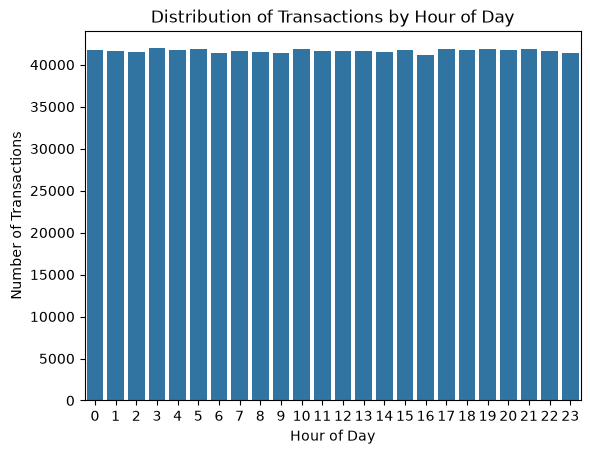

In [36]:
sns.countplot(
    data = df,
    x = "hour_of_day",
    order = sorted(df["hour_of_day"].unique())
)

plt.title("Distribution of Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

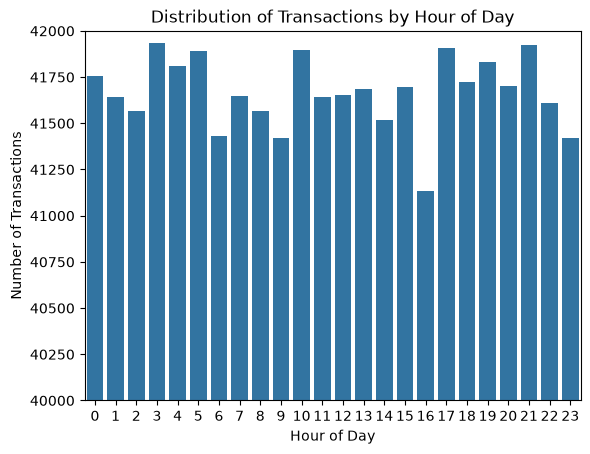

In [37]:
sns.countplot(
    data = df,
    x = "hour_of_day",
    order = sorted(df["hour_of_day"].unique())
)

plt.ylim(40000, 42000)

plt.title("Distribution of Transactions by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.show()

##### Observation

- Transactions are distributed fairly uniformly across all hours of the day, with no significant peaks or periods of exceptionally low activity.
- The transaction count for each hour ranges from approximately **41,100 to 41,900**, indicating only minor variations in transaction volume throughout the day.
- The relatively even distribution suggests that customer transactions occur consistently across the entire day rather than being concentrated during specific hours.
- No unusual spikes or anomalies are observed in the hourly transaction distribution.

#### Distribution of Distance from Home

Distance from home represents the distance between a customer's registered home location and the location where a transaction was performed. Analyzing its distribution helps understand typical transaction distances, identify unusual travel patterns, and detect extreme values that may be relevant for subsequent fraud-related analyses.

##### Analysis Objective

To examine the distribution of transaction distances from customers' homes, identify the most common transaction distance ranges, detect potential outliers, and gain insights into customer transaction behavior across different locations.

In [38]:
df["distance_from_home_km"].median()

np.float64(13.9)

In [39]:
df["distance_from_home_km"].describe()

count    1000000.000000
mean          20.009890
std           20.011427
min            0.000000
25%            5.800000
50%           13.900000
75%           27.700000
max          292.100000
Name: distance_from_home_km, dtype: float64

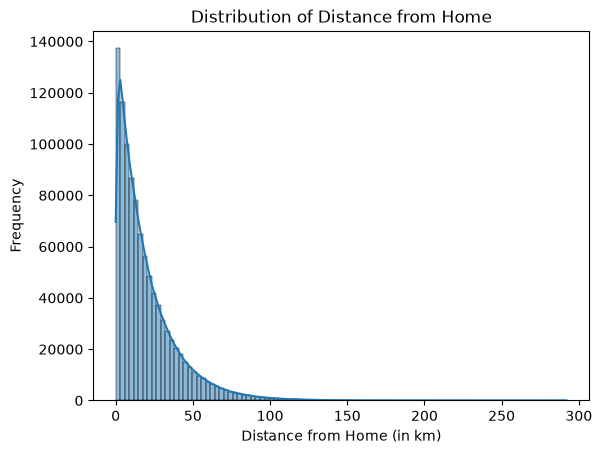

In [40]:
sns.histplot(
    df["distance_from_home_km"],
    bins = 100,
    kde = True
)

plt.title("Distribution of Distance from Home")
plt.xlabel("Distance from Home (in km)")
plt.ylabel("Frequency")

plt.show()

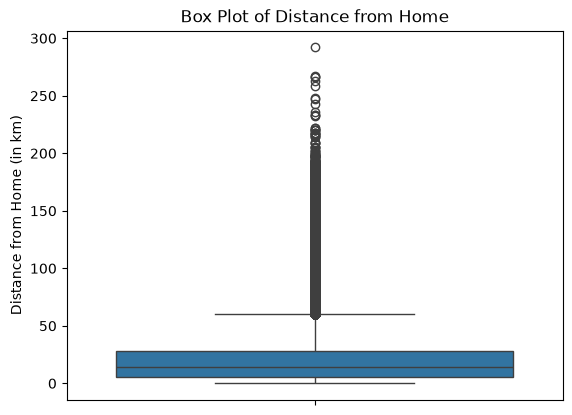

In [41]:
sns.boxplot(
    df["distance_from_home_km"]
)

plt.ylabel("Distance from Home (in km)")
plt.title("Box Plot of Distance from Home")

plt.show()

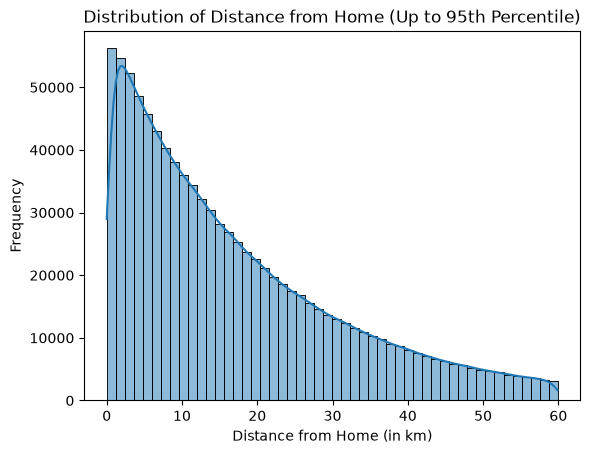

In [42]:
limit = df["distance_from_home_km"].quantile(0.95)

sns.histplot(
    df[df["distance_from_home_km"] <= limit]["distance_from_home_km"],
    bins = 50,
    kde = True
)

plt.xlabel("Distance from Home (in km)")
plt.ylabel("Frequency")
plt.title("Distribution of Distance from Home (Up to 95th Percentile)")

plt.show()

##### Observation

- Transaction distances from customers' homes range from **0.0 km to 292.1 km**, indicating substantial variation in where transactions are performed.
- The mean distance (20.01 km) is higher than the median (13.9 km), suggesting a moderately right-skewed distribution.
- Half of the transactions occur within **5.8 km to 27.7 km** of the customer's home, indicating that most transactions are performed relatively close to home.
- A small number of transactions occur at considerably greater distances, resulting in several high-distance outliers.

#### Distribution of Time Since Last Transaction

Time since the last transaction represents the elapsed time between a customer's current transaction and their previous transaction. Analyzing its distribution helps understand customer transaction frequency, identify common intervals between transactions, and detect unusually short or long gaps that may be relevant for subsequent fraud-related analyses.

##### Analysis Objective

To examine the distribution of the time elapsed since customers' previous transactions, identify the most common transaction intervals, detect potential outliers, and gain insights into customer transaction patterns over time.

In [43]:
df["time_since_last_txn_hrs"].median()

np.float64(8.32)

In [44]:
df["time_since_last_txn_hrs"].describe()

count    1000000.000000
mean          12.000945
std           11.999904
min            0.000000
25%            3.450000
50%            8.320000
75%           16.630000
max          154.200000
Name: time_since_last_txn_hrs, dtype: float64

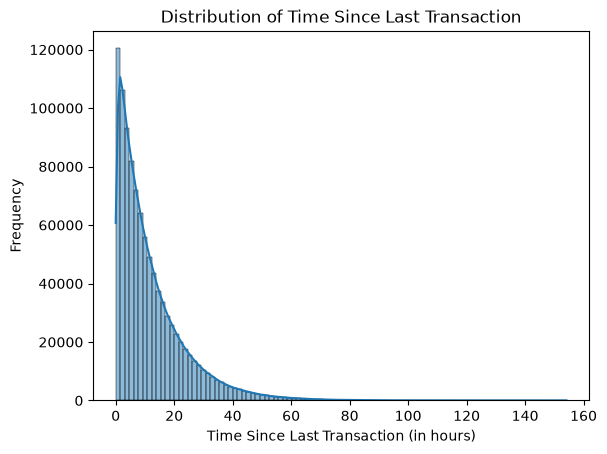

In [45]:
sns.histplot(
    df["time_since_last_txn_hrs"],
    bins = 100,
    kde = True
)

plt.title("Distribution of Time Since Last Transaction")
plt.xlabel("Time Since Last Transaction (in hours)")
plt.ylabel("Frequency")

plt.show()

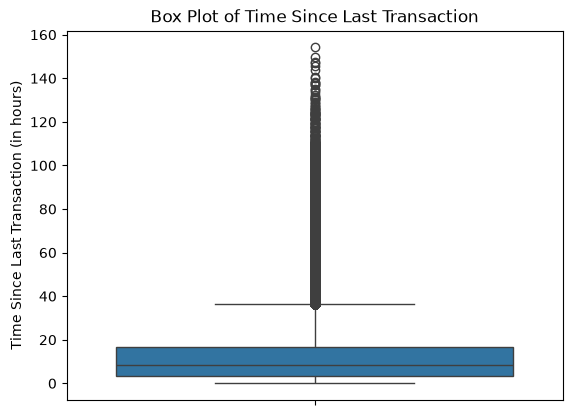

In [46]:
sns.boxplot(
    df["time_since_last_txn_hrs"]
)

plt.ylabel("Time Since Last Transaction (in hours)")
plt.title("Box Plot of Time Since Last Transaction")

plt.show()

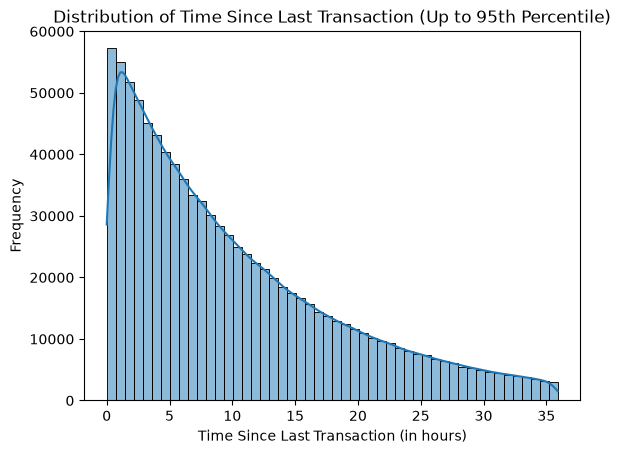

In [47]:
limit = df["time_since_last_txn_hrs"].quantile(0.95)

sns.histplot(
    df[df["time_since_last_txn_hrs"] <= limit]["time_since_last_txn_hrs"],
    bins=50,
    kde=True
)

plt.title("Distribution of Time Since Last Transaction (Up to 95th Percentile)")
plt.xlabel("Time Since Last Transaction (in hours)")
plt.ylabel("Frequency")

plt.show()

##### Observation

- The time elapsed since the previous transaction ranges from **0.0 to 154.2 hours**, indicating considerable variation in customer transaction intervals.
- The mean interval (12.00 hours) is higher than the median (8.32 hours), suggesting a moderately right-skewed distribution.
- Half of the transactions occur between **3.45 and 16.63 hours** after the previous transaction, indicating that most customers perform transactions within relatively short time intervals.
- A small number of transactions exhibit substantially longer intervals, resulting in several high-value outliers.

#### Distribution of Previous Transactions

The number of previous transactions represents the total transactions completed by a customer prior to the current transaction. Analyzing its distribution helps understand customers' transaction history, identify varying levels of transaction activity, and detect unusually low or high transaction counts that may influence subsequent fraud-related analyses.

##### Analysis Objective

To examine the distribution of customers' previous transaction counts, identify the most common transaction activity levels, detect potential outliers, and gain insights into customers' historical transaction behavior.

In [48]:
df["num_prev_transactions"].median()

np.float64(150.0)

In [49]:
df["num_prev_transactions"].describe()

count    1000000.000000
mean         149.996350
std           12.244379
min           96.000000
25%          142.000000
50%          150.000000
75%          158.000000
max          213.000000
Name: num_prev_transactions, dtype: float64

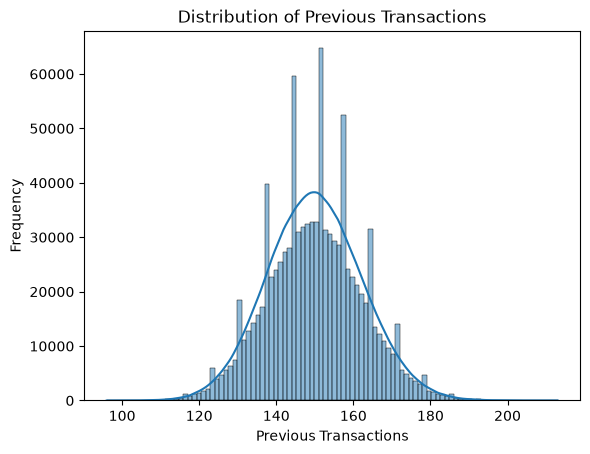

In [50]:
sns.histplot(
    df["num_prev_transactions"],
    bins = 100,
    kde = True
)

plt.title("Distribution of Previous Transactions")
plt.xlabel("Previous Transactions")
plt.ylabel("Frequency")

plt.show()

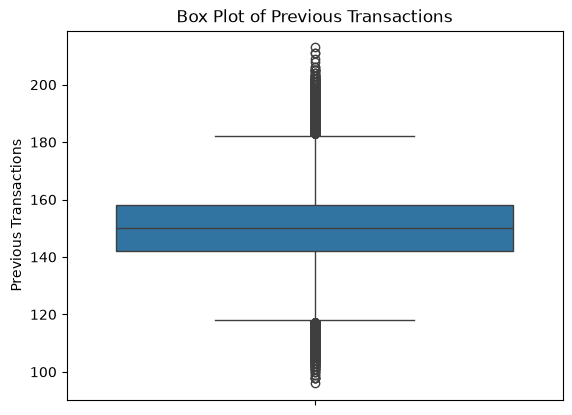

In [51]:
sns.boxplot(
    df["num_prev_transactions"]
)

plt.ylabel("Previous Transactions")
plt.title("Box Plot of Previous Transactions")

plt.show()

##### Observation

- The number of previous transactions ranges from **96 to 213**, indicating moderate variation in customers' historical transaction counts.
- The mean (150.00) is nearly identical to the median (150), suggesting an approximately symmetric distribution.
- Half of the customers have completed between **142 and 158** previous transactions, indicating that most customers possess a similar level of transaction history.
- No extreme deviations or unusual transaction count values are observed within the dataset.

#### Distribution of Monthly Transaction Frequency

Monthly transaction frequency represents the average number of transactions performed by a customer within a month. Analyzing its distribution helps understand customers' transaction activity levels, identify common frequency patterns, and detect unusually low or high transaction frequencies that may provide useful context for subsequent fraud-related analyses.

##### Analysis Objective

To examine the distribution of customers' monthly transaction frequency, identify the most common transaction frequency ranges, detect potential outliers, and gain insights into customers' overall transaction activity patterns.

In [52]:
df["transaction_freq_monthly"].median()

np.float64(20.0)

In [53]:
df["transaction_freq_monthly"].describe()

count    1000000.000000
mean          19.999322
std            4.474045
min            2.000000
25%           17.000000
50%           20.000000
75%           23.000000
max           44.000000
Name: transaction_freq_monthly, dtype: float64

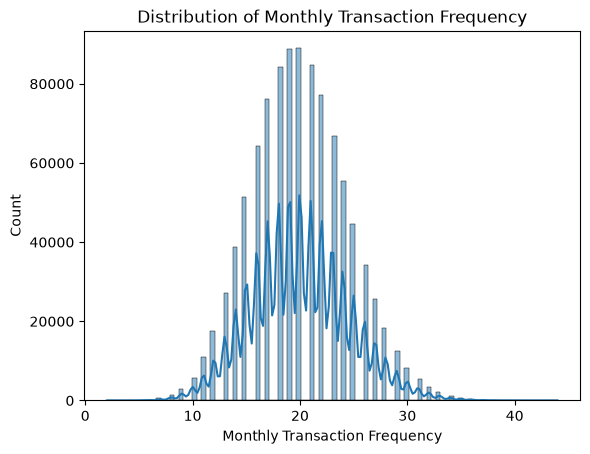

In [54]:
sns.histplot(
    df["transaction_freq_monthly"],
    bins = 100,
    kde = True
)

plt.title("Distribution of Monthly Transaction Frequency")
plt.xlabel("Monthly Transaction Frequency")
plt.ylabel("Count")

plt.show()

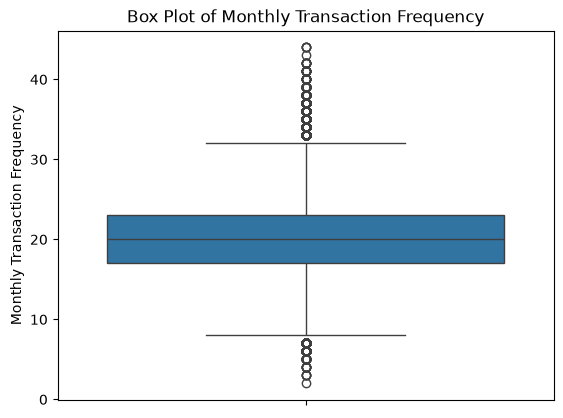

In [55]:
sns.boxplot(
    df["transaction_freq_monthly"]
)

plt.ylabel("Monthly Transaction Frequency")
plt.title("Box Plot of Monthly Transaction Frequency")

plt.show()

##### Observation

- Monthly transaction frequency ranges from **2 to 44 transactions**, indicating moderate variation in customers' monthly transaction activity.
- The mean monthly transaction frequency (19.99) is nearly identical to the median (20), suggesting an approximately symmetric distribution.
- Half of the customers perform between **17 and 23 transactions per month**, indicating that most customers exhibit a consistent level of monthly transaction activity.
- No significant skewness or unusual transaction frequency values are observed in the dataset.

### TRANSACTION CHARACTERISTICS

#### Distribution of Merchant Categories

Merchant category represents the type of business or service where a transaction was performed. Analyzing its distribution helps identify the most common types of merchants, understand customer spending patterns across different sectors, and examine the diversity of transaction categories within the dataset.

##### Analysis Objective

To examine the distribution of merchant categories, identify the most frequently occurring transaction categories, and gain insights into customers' spending behavior across different types of merchants.

In [56]:
df["merchant_category"].unique()

<ArrowStringArray>
[        'Grocery',      'Healthcare',       'Utilities',        'Clothing',
 'Crypto Exchange',       'Education', 'Online Shopping',         'Jewelry',
     'Electronics',  'ATM Withdrawal',            'Fuel',      'Restaurant',
          'Travel',   'Entertainment',          'Gaming']
Length: 15, dtype: str

In [57]:
df["merchant_category"].value_counts()

merchant_category
Entertainment      67150
Jewelry            66870
Electronics        66866
Fuel               66843
Utilities          66841
Education          66816
Clothing           66792
Travel             66692
Restaurant         66628
Healthcare         66613
Grocery            66513
ATM Withdrawal     66389
Online Shopping    66341
Gaming             66338
Crypto Exchange    66308
Name: count, dtype: int64

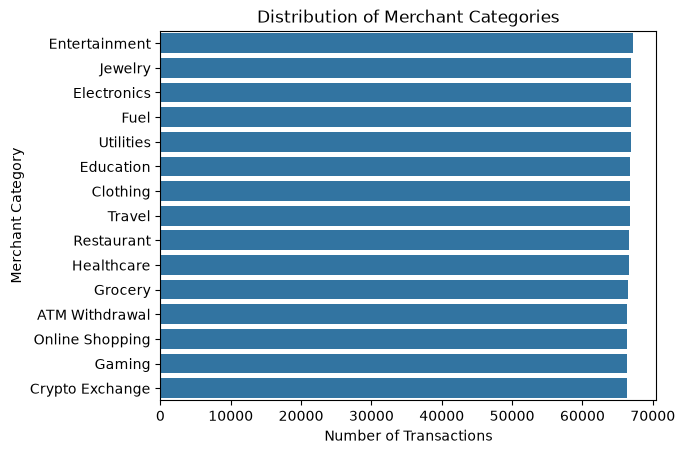

In [58]:
sns.countplot(
    df["merchant_category"],
    order=df["merchant_category"].value_counts().index
)

plt.title("Distribution of Merchant Categories")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Category")

plt.show()

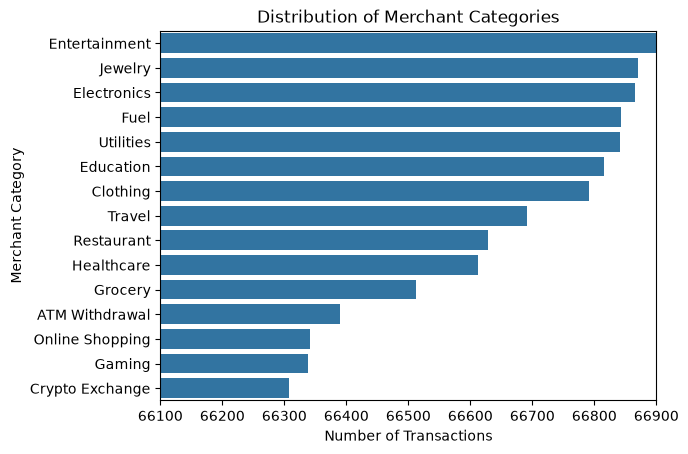

In [59]:
sns.countplot(
    df["merchant_category"],
    order=df["merchant_category"].value_counts().index
)

plt.xlim(66100,66900)

plt.title("Distribution of Merchant Categories")
plt.xlabel("Number of Transactions")
plt.ylabel("Merchant Category")

plt.show()

##### Observation

- The dataset contains transactions across **15 distinct merchant categories**, representing a diverse range of customer spending activities.
- Transaction counts are distributed fairly uniformly across all merchant categories, with each category accounting for approximately **66,000 to 67,000 transactions**.
- **Entertainment**, **Jewelry**, and **Electronics** are the most frequently occurring merchant categories, although the differences in transaction counts are minimal.
- No merchant category overwhelmingly dominates the dataset, indicating a balanced representation of transaction types.

#### Distribution of Payment Methods

Payment method represents the mode through which a customer completes a transaction. Analyzing its distribution helps identify the most commonly used payment methods, understand customer payment preferences, and assess the diversity of payment options represented in the dataset.

##### Analysis Objective

To examine the distribution of payment methods, identify the most frequently used transaction methods, and gain insights into customers' preferred modes of payment.

In [60]:
df["payment_method"].unique()

<ArrowStringArray>
[ 'Bank Transfer',         'Cheque',         'Crypto',     'Debit Card',
    'Credit Card', 'Mobile Payment']
Length: 6, dtype: str

In [61]:
df["payment_method"].value_counts()

payment_method
Credit Card       349618
Debit Card        300860
Bank Transfer     150029
Mobile Payment    119697
Crypto             50158
Cheque             29638
Name: count, dtype: int64

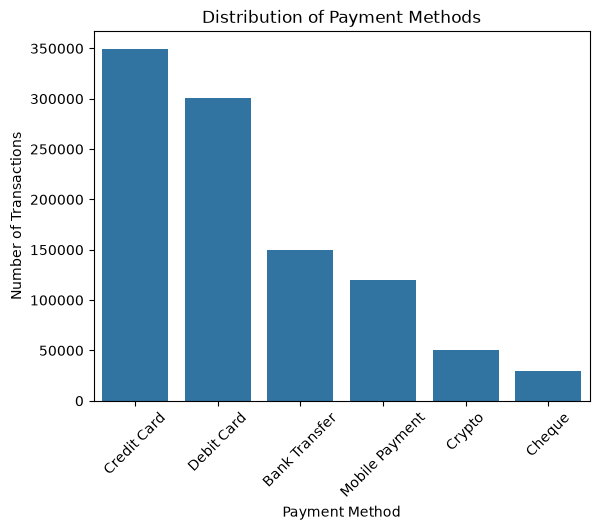

In [62]:
sns.countplot(
    data=df,
    x="payment_method",
    order=df["payment_method"].value_counts().index
)

plt.title("Distribution of Payment Methods")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

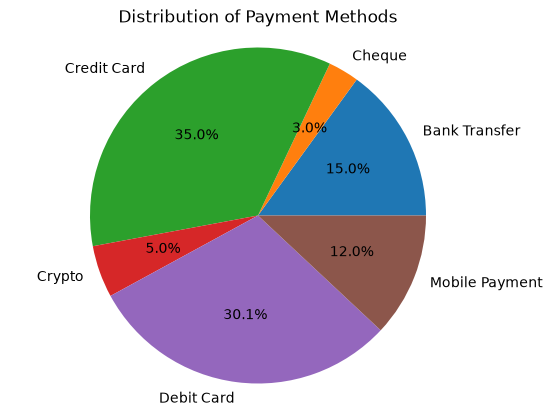

In [63]:
plt.pie(
    df["payment_method"].value_counts().sort_index(),
    labels=["Bank Transfer", "Cheque", "Credit Card", "Crypto", "Debit Card", "Mobile Payment"],
    autopct="%1.1f%%",
)

plt.title("Distribution of Payment Methods")

plt.axis("equal")

plt.show()

##### Observation

- The dataset includes **six distinct payment methods**, representing a variety of transaction channels.
- **Credit Card** is the most frequently used payment method, accounting for approximately **349,600 transactions**, followed by **Debit Card** with around **300,900 transactions**.
- **Bank Transfer** and **Mobile Payment** exhibit moderate usage, whereas **Crypto** and **Cheque** are the least frequently used payment methods.
- The distribution indicates that customers show clear preferences for card-based payment methods over other available transaction options.

#### Distribution of Device Types

Device type represents the category of device used by customers to perform a transaction. Analyzing its distribution helps identify the most commonly used devices, understand customer transaction preferences across different platforms, and assess the diversity of devices represented in the dataset.

##### Analysis Objective

To examine the distribution of device types, identify the most frequently used devices for performing transactions, and gain insights into customers' preferred transaction platforms.

In [64]:
df["device_type"].unique()

<ArrowStringArray>
['POS Terminal', 'Desktop', 'Mobile', 'ATM', 'Tablet']
Length: 5, dtype: str

In [65]:
df["device_type"].value_counts()

device_type
Mobile          449114
Desktop         249830
ATM             100995
Tablet          100101
POS Terminal     99960
Name: count, dtype: int64

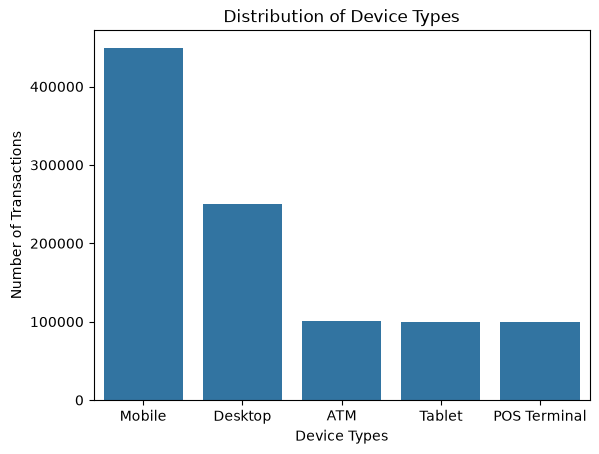

In [66]:
sns.countplot(
    data=df,
    x="device_type",
    order=df["device_type"].value_counts().index
)

plt.title("Distribution of Device Types")
plt.xlabel("Device Types")
plt.ylabel("Number of Transactions")

plt.show()

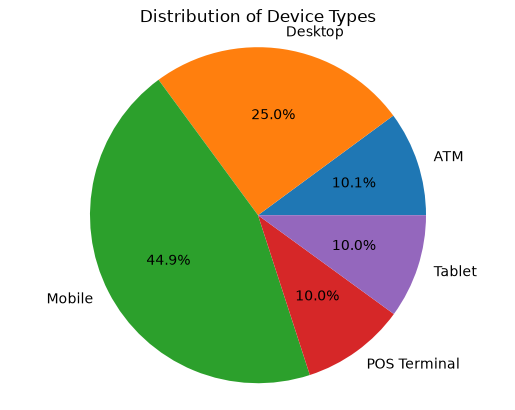

In [67]:
plt.pie(
    df["device_type"].value_counts().sort_index(),
    labels=["ATM", "Desktop", "Mobile", "POS Terminal", "Tablet"],
    autopct="%1.1f%%",
)

plt.title("Distribution of Device Types")

plt.axis("equal")

plt.show()

##### Observation

- The dataset contains transactions originating from **five distinct device types**, representing multiple transaction platforms.
- **Mobile** devices are the most commonly used, accounting for approximately **449,100 transactions**, followed by **Desktop** devices with nearly **249,800 transactions**.
- **ATM**, **Tablet**, and **POS Terminal** contribute a comparatively smaller but fairly similar number of transactions, each accounting for approximately **100,000 transactions**.
- The distribution indicates that customers predominantly perform transactions using mobile devices, reflecting a strong preference for mobile banking and digital payment platforms.

### BINARY FEATURES

#### Distribution of Weekend Transactions

The weekend transaction indicator specifies whether a transaction occurred on a weekend or a weekday. Analyzing its distribution helps understand the proportion of transactions performed during weekends and provides insight into customers' transaction activity across different days of the week.

##### Analysis Objective

To examine the distribution of weekend and weekday transactions, determine the proportion of transactions occurring on weekends, and gain insights into customers' transaction patterns across the week.

In [68]:
df["is_weekend"].value_counts()

is_weekend
0    713978
1    286022
Name: count, dtype: int64

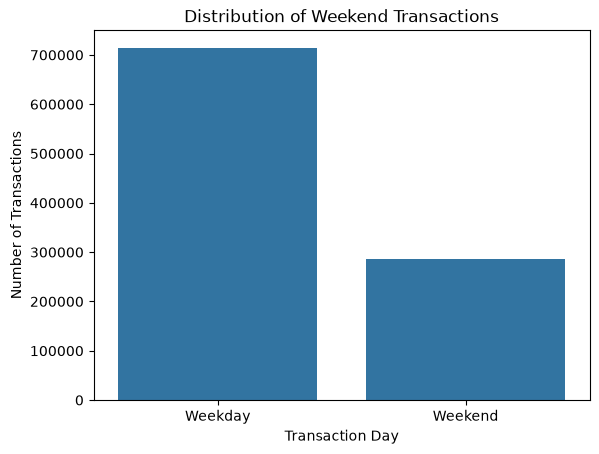

In [69]:
sns.countplot(
    data=df,
    x="is_weekend"
)

plt.xticks(ticks=[0, 1], labels=["Weekday", "Weekend"])

plt.title("Distribution of Weekend Transactions")
plt.xlabel("Transaction Day")
plt.ylabel("Number of Transactions")

plt.show()

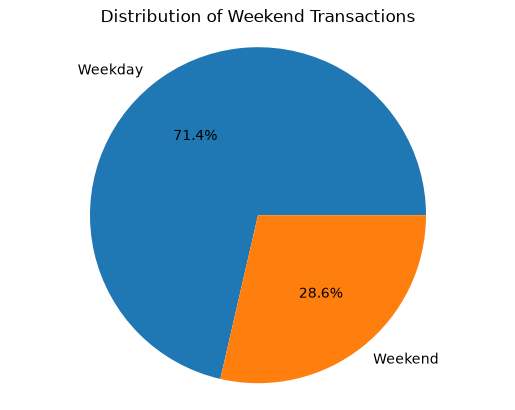

In [70]:
plt.pie(
    df["is_weekend"].value_counts().sort_index(),
    labels=["Weekday", "Weekend"],
    autopct="%1.1f%%",
)

plt.title("Distribution of Weekend Transactions")

plt.axis("equal")

plt.show()

##### Observation

- Approximately **71.4%** of transactions occur on **weekdays**, while **28.6%** take place on **weekends**.
- Weekday transactions substantially outnumber weekend transactions, indicating that customer transaction activity is higher during the working week.
- The distribution reflects a greater concentration of transactions on weekdays than on weekends.

#### Distribution of Night Transactions

The night transaction indicator specifies whether a transaction occurred during nighttime hours. Analyzing its distribution helps understand the proportion of transactions performed at night versus during the day and provides insight into customers' transaction activity across different times of the day.

##### Analysis Objective

To examine the distribution of daytime and nighttime transactions, determine the proportion of transactions occurring during nighttime hours, and gain insights into customers' transaction patterns throughout the day.

In [71]:
df["is_night_transaction"].value_counts()

is_night_transaction
0    624943
1    375057
Name: count, dtype: int64

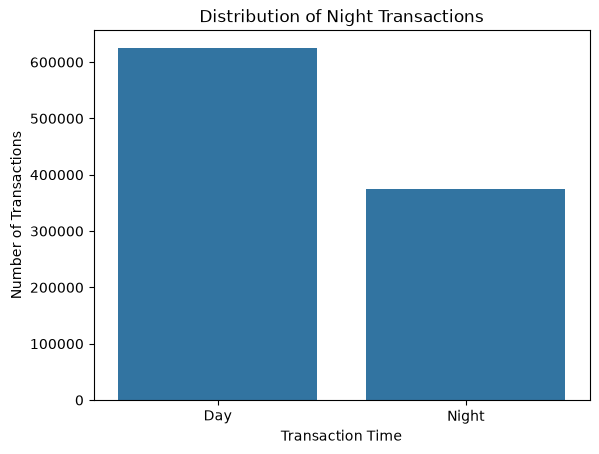

In [72]:
sns.countplot(
    data=df,
    x="is_night_transaction"
)

plt.xticks(ticks=[0, 1], labels=["Day", "Night"])

plt.title("Distribution of Night Transactions")
plt.xlabel("Transaction Time")
plt.ylabel("Number of Transactions")

plt.show()

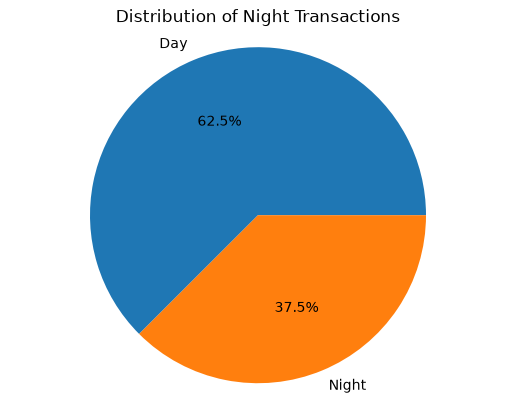

In [73]:
plt.pie(
    df["is_night_transaction"].value_counts().sort_index(),
    labels=["Day", "Night"],
    autopct="%1.1f%%",
)

plt.title("Distribution of Night Transactions")

plt.axis("equal")

plt.show()

##### Observation

- Approximately **62.5%** of transactions occur during the **daytime**, while **37.5%** take place during **nighttime hours**.
- Daytime transactions are more frequent than nighttime transactions, indicating that customers are generally more active during the day.
- Despite the higher volume of daytime transactions, a substantial proportion of transactions also occur at night, reflecting transaction activity throughout the entire day.

#### Distribution of International Transactions

The international transaction indicator specifies whether a transaction was performed outside the customer's home country. Analyzing its distribution helps understand the proportion of domestic and international transactions and provides insight into the geographical nature of customer transaction activity.

##### Analysis Objective

To examine the distribution of domestic and international transactions, determine the proportion of transactions conducted internationally, and gain insights into the geographical transaction patterns of customers.

In [74]:
df["is_international"].value_counts()

is_international
0    850006
1    149994
Name: count, dtype: int64

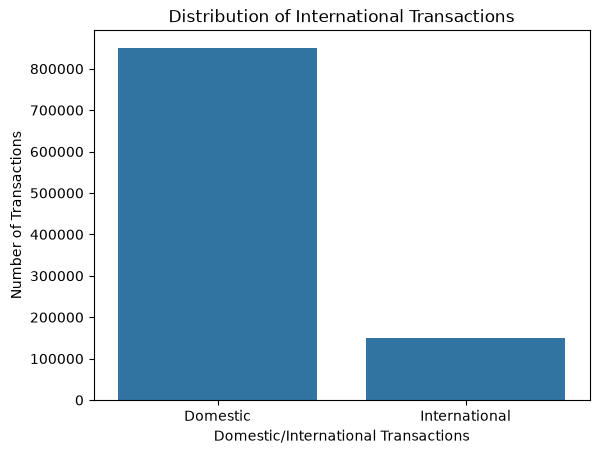

In [75]:
sns.countplot(
    data=df,
    x="is_international"
)

plt.xticks(ticks=[0, 1], labels=["Domestic", "International"])

plt.title("Distribution of International Transactions")
plt.xlabel("Domestic/International Transactions")
plt.ylabel("Number of Transactions")

plt.show()

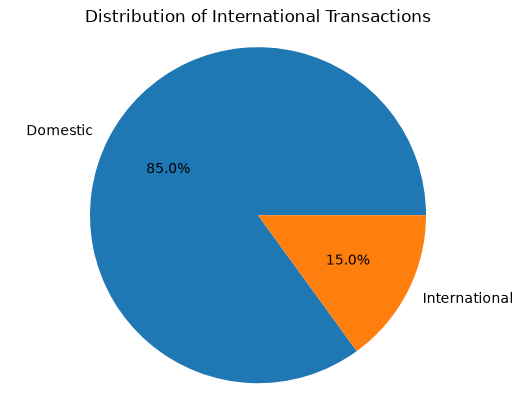

In [76]:
plt.pie(
    df["is_international"].value_counts().sort_index(),
    labels=["Domestic", "International"],
    autopct="%1.1f%%",
)

plt.title("Distribution of International Transactions")

plt.axis("equal")

plt.show()

##### Observation

- Approximately **85.0%** of transactions are **domestic**, while **15.0%** are **international**.
- Domestic transactions constitute the vast majority of the dataset, indicating that most customer transactions occur within their home country.
- International transactions represent a smaller but meaningful proportion of the overall transaction activity.

#### Distribution of Recent PIN Changes

The recent PIN change indicator specifies whether a customer has changed their account PIN within a recent period. Analyzing its distribution helps understand how frequently customers update their PINs and provides insight into the prevalence of recent credential changes within the dataset.

##### Analysis Objective

To examine the distribution of customers who have and have not changed their PIN recently, determine the proportion of recent PIN changes, and gain insights into customers' account security practices.

In [77]:
df["pin_changed_recently"].value_counts()

pin_changed_recently
0    919561
1     80439
Name: count, dtype: int64

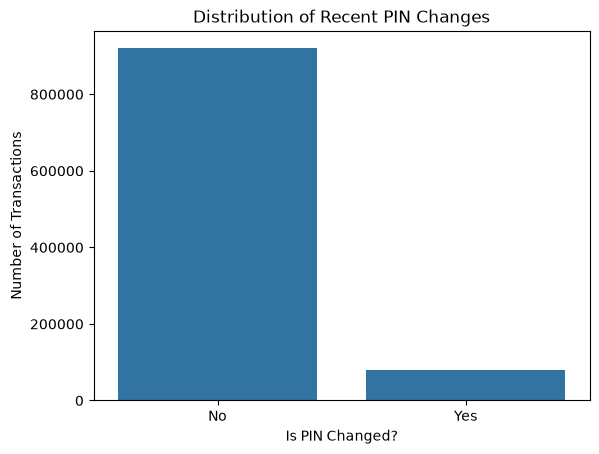

In [78]:
sns.countplot(
    data=df,
    x="pin_changed_recently"
)

plt.xticks(ticks=[0, 1], labels=["No", "Yes"])

plt.title("Distribution of Recent PIN Changes")
plt.xlabel("Is PIN Changed?")
plt.ylabel("Number of Transactions")

plt.show()

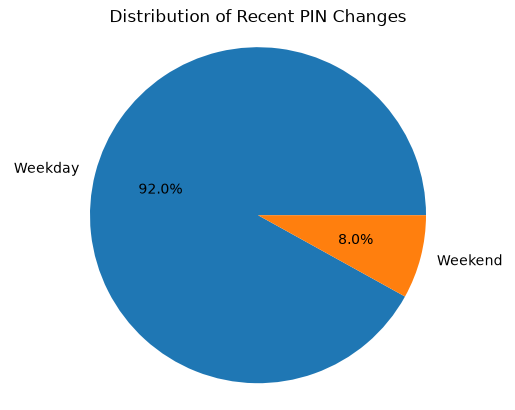

In [79]:
plt.pie(
    df["pin_changed_recently"].value_counts().sort_index(),
    labels=["Weekday", "Weekend"],
    autopct="%1.1f%%",
)

plt.title("Distribution of Recent PIN Changes")

plt.axis("equal")

plt.show()

##### Observation

- Approximately **92.0%** of customers have **not changed their PIN recently**, while **8.0%** have performed a recent PIN change.
- Recent PIN changes represent a relatively small proportion of the dataset, indicating that most customers retain the same PIN over the observed period.
- The distribution suggests that recent PIN updates are comparatively infrequent among customers.

#### Distribution of Fraudulent Transactions

The fraud indicator specifies whether a transaction is classified as fraudulent or legitimate. Analyzing its distribution helps understand the proportion of fraudulent transactions within the dataset, assess the balance between the two classes, and establish a foundation for subsequent fraud-focused analyses.

##### Analysis Objective

To examine the distribution of fraudulent and legitimate transactions, determine the prevalence of fraud within the dataset, and gain insights into the overall class distribution before conducting further exploratory and comparative analyses.

In [80]:
df["is_fraud"].value_counts()

is_fraud
0    944745
1     55255
Name: count, dtype: int64

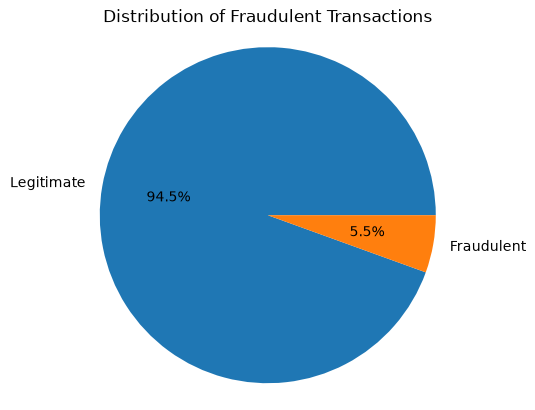

In [81]:
plt.pie(
    df["is_fraud"].value_counts().sort_index(),
    labels=["Legitimate", "Fraudulent"],
    autopct="%1.1f%%",
)

plt.title("Distribution of Fraudulent Transactions")

plt.axis("equal")

plt.show()

##### Observation

- Approximately **94.5%** of transactions are classified as **legitimate**, while **5.53%** are identified as **fraudulent**.
- Legitimate transactions constitute the overwhelming majority of the dataset, indicating a clear class imbalance between legitimate and fraudulent transactions.
- Although fraudulent transactions represent a relatively small proportion of the dataset, they account for more than **55,000** instances, providing a substantial number of fraud cases for subsequent analysis.

### SECURITY FEATURES

#### Distribution of Failed Authentication Attempts

Failed authentication attempts represent the number of unsuccessful attempts made before a transaction was completed. Analyzing its distribution helps understand the frequency of failed authentication events, identify common attempt counts, and detect unusually high numbers of failed attempts that may indicate abnormal transaction behavior.

##### Analysis Objective

To examine the distribution of failed authentication attempts, identify the most common numbers of unsuccessful attempts, detect potential outliers, and gain insights into authentication patterns associated with customer transactions.

In [82]:
df["failed_attempts"].describe()

count    1000000.000000
mean           0.380072
std            0.914603
min            0.000000
25%            0.000000
50%            0.000000
75%            0.000000
max            5.000000
Name: failed_attempts, dtype: float64

In [83]:
df["failed_attempts"].value_counts().sort_index()

failed_attempts
0    800037
1     99962
2     50038
3     29896
4      9989
5     10078
Name: count, dtype: int64

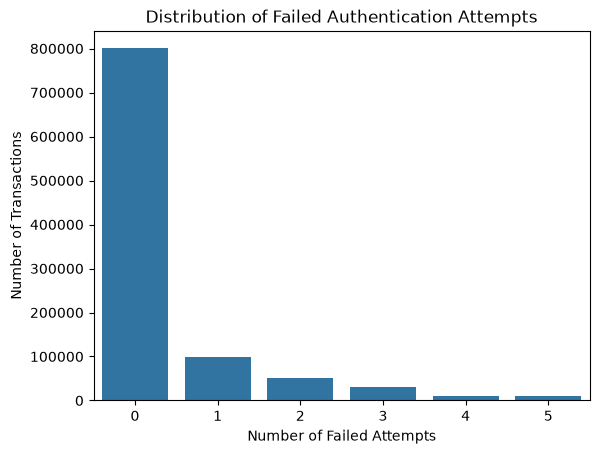

In [84]:
sns.countplot(
    data=df,
    x="failed_attempts"
)

plt.title("Distribution of Failed Authentication Attempts")
plt.xlabel("Number of Failed Attempts")
plt.ylabel("Number of Transactions")

plt.show()

##### Observation

- The majority of transactions (**80.0%**) are completed without any failed authentication attempts.
- As the number of failed attempts increases, the frequency of transactions generally decreases, indicating that multiple failed authentication attempts are relatively uncommon.
- Transactions involving four or five failed attempts constitute only a small proportion of the dataset.
- Overall, the distribution is concentrated at **zero failed attempts**, with progressively fewer transactions recorded for higher numbers of failed attempts.

### FRAUD CLASSIFICATION

#### Distribution of Fraud Types

Fraud type represents the specific category of fraudulent activity associated with a transaction. Analyzing its distribution helps understand the prevalence of different fraud schemes, identify the most common types of fraud within the dataset, and provide a clearer picture of the fraud landscape represented in the data.

##### Analysis Objective

To examine the distribution of fraud types among fraudulent transactions, identify the most prevalent fraud categories, and gain insights into the variety of fraudulent activities present in the dataset.

In [85]:
fraud_df = df[df["is_fraud"] == 1]

fraud_df["fraud_type"].value_counts()

fraud_type
Phishing              9252
Account Takeover      9232
Synthetic Identity    9214
Card Cloning          9200
Friendly Fraud        9187
Identity Theft        9170
Name: count, dtype: int64

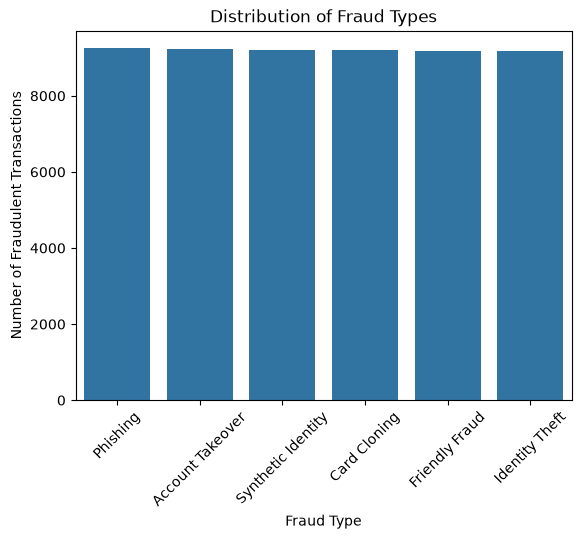

In [86]:
fraud_df = df[df["is_fraud"] == 1]

sns.countplot(
    data=fraud_df,
    x="fraud_type",
    order=fraud_df["fraud_type"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Distribution of Fraud Types")
plt.ylabel("Number of Fraudulent Transactions")
plt.xlabel("Fraud Type")

plt.show()

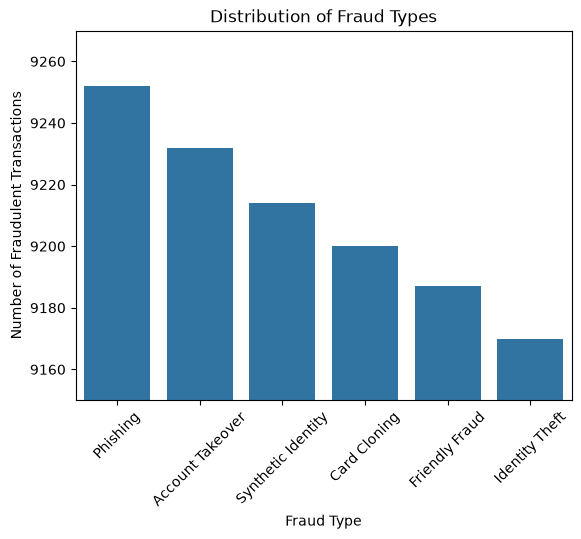

In [87]:
fraud_df = df[df["is_fraud"] == 1]

sns.countplot(
    data=fraud_df,
    x="fraud_type",
    order=fraud_df["fraud_type"].value_counts().index
)

plt.xticks(rotation=45)
plt.ylim(9150, 9270)

plt.title("Distribution of Fraud Types")
plt.ylabel("Number of Fraudulent Transactions")
plt.xlabel("Fraud Type")

plt.show()

##### Observation

- The fraudulent transactions are categorized into **six distinct fraud types**, representing a diverse range of fraudulent activities.
- **Phishing** is the most frequently occurring fraud type, closely followed by **Account Takeover**, **Synthetic Identity**, **Card Cloning**, **Friendly Fraud**, and **Identity Theft**.
- The number of transactions across all fraud categories is relatively similar, with each fraud type accounting for approximately **9,200 fraudulent transactions**.
- No single fraud type overwhelmingly dominates the dataset, indicating a balanced representation of different fraud categories.

### GEOGRAPHIC FEATURES

#### Distribution of Countries

The country feature represents the country in which each transaction was performed. Analyzing its distribution helps identify the geographical spread of transactions, determine the most frequently represented countries, and understand the overall distribution of transaction activity across different regions.

##### Analysis Objective

To examine the distribution of transactions across countries, identify the most frequently represented countries, and gain insights into the geographical distribution of customer transactions.

In [88]:
df["country"].value_counts()

country
USA          299910
India        120206
UK            99677
Brazil        80351
Germany       79831
Japan         70107
France        69867
Canada        69742
Mexico        60275
Australia     50034
Name: count, dtype: int64

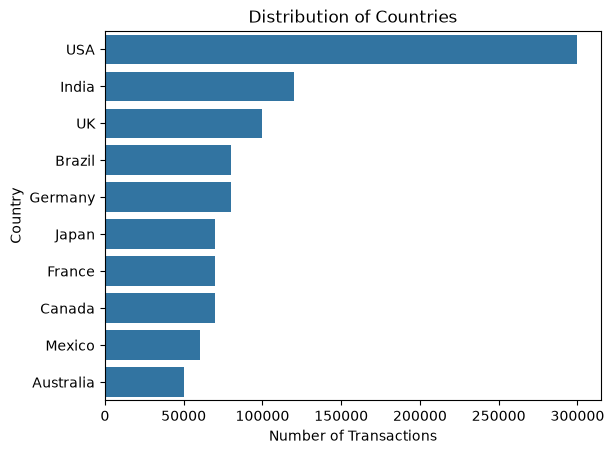

In [89]:
sns.countplot(
    data=df,
    y="country",
    order=df["country"].value_counts().index
)

plt.title("Distribution of Countries")
plt.xlabel("Number of Transactions")
plt.ylabel("Country")

plt.show()

##### Observation

- The dataset contains transactions from **ten different countries**, representing a geographically diverse customer base.
- The **United States (USA)** has the highest number of transactions, accounting for approximately **299,900 transactions**, making it the most represented country in the dataset.
- **India** and the **United Kingdom (UK)** are the second and third most represented countries, followed by **Brazil**, **Germany**, **Japan**, **France**, **Canada**, **Mexico**, and **Australia**.
- The distribution is uneven across countries, with the USA contributing a substantially larger share of transactions than the other represented nations.

#### Distribution of Cities

The city feature represents the city in which each transaction was performed. Analyzing its distribution helps identify the geographical concentration of transactions, determine the most frequently represented cities, and understand how transaction activity is distributed across different urban locations.

##### Analysis Objective

To examine the distribution of transactions across cities, identify the most frequently represented cities, and gain insights into the geographical distribution of customer transaction activity at the city level.

In [90]:
df["city"].value_counts()

city
Rio            50365
Melbourne      50329
Guadalajara    50259
Sydney         50206
São Paulo      50192
Manchester     50147
Mumbai         50078
Delhi          50062
Los Angeles    50062
Osaka          50047
Toronto        50029
Mexico City    50005
Berlin         50001
Paris          49917
Lyon           49881
Vancouver      49828
Tokyo          49687
Munich         49653
New York       49639
London         49613
Name: count, dtype: int64

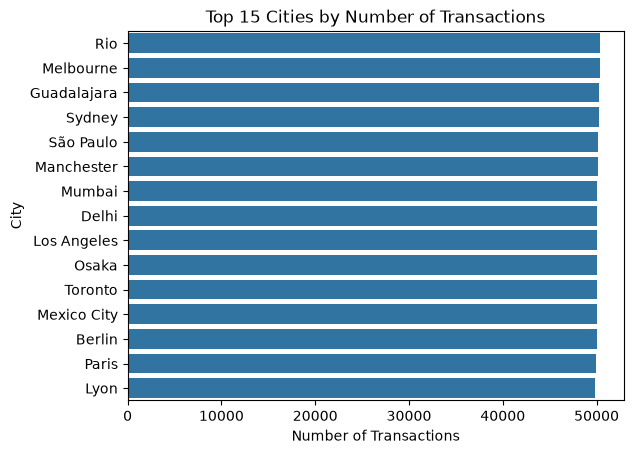

In [91]:
top_cities = df["city"].value_counts().head(15)

sns.barplot(
    x=top_cities.values,
    y=top_cities.index
)

plt.title("Top 15 Cities by Number of Transactions")
plt.xlabel("Number of Transactions")
plt.ylabel("City")

plt.show()

##### Observation

- The dataset contains transactions from **20 different cities**, providing broad geographical coverage across multiple countries.
- Transaction counts are distributed relatively evenly among the cities, with each city contributing approximately **50,000 transactions**.
- **Rio**, **Melbourne**, and **Guadalajara** are the three most represented cities, while **Tokyo**, **Munich**, **New York**, and **London** have slightly lower transaction counts.
- The variation in transaction volume across cities is minimal, indicating a well-balanced representation of urban locations within the dataset.

## Bivariate Analysis

Bivariate analysis examines the relationship between two variables to identify patterns, trends, and potential associations within the dataset. In this project, the primary objective is to investigate how different customer, financial, transaction, geographic, and security-related features vary between legitimate and fraudulent transactions. These analyses provide valuable insights into the characteristics that may be associated with fraudulent behavior.

### FINANCIAL FEATURES vs FRAUD

#### Transaction Amount vs Fraud

Research Question: **Do fraudulent transactions generally involve higher or lower transaction amounts than legitimate transactions?**

In [92]:
df.groupby("is_fraud")["transaction_amount"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,203.358743,453.955126,1.0,33.370,72.95,180.700,46129.60
1,55255.0,228.079082,546.165534,1.0,34.005,76.10,194.075,14767.61


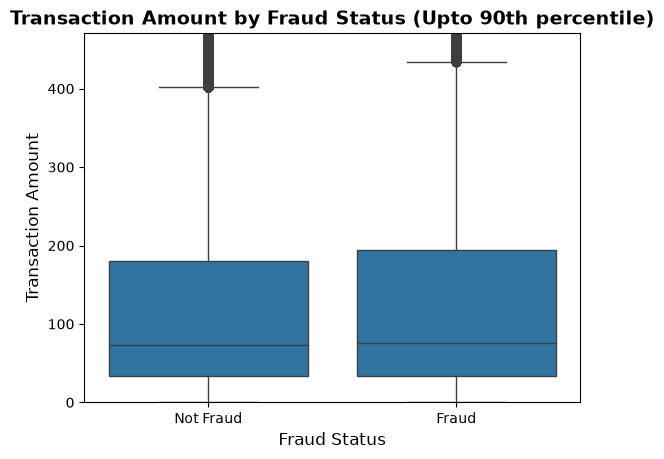

In [93]:
upper_limit = df["transaction_amount"].quantile(0.90)

sns.boxplot(
    data=df,
    x="is_fraud",
    y="transaction_amount"
)

plt.title("Transaction Amount by Fraud Status (Upto 90th percentile)", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Transaction Amount", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.ylim(0, upper_limit)

plt.show()

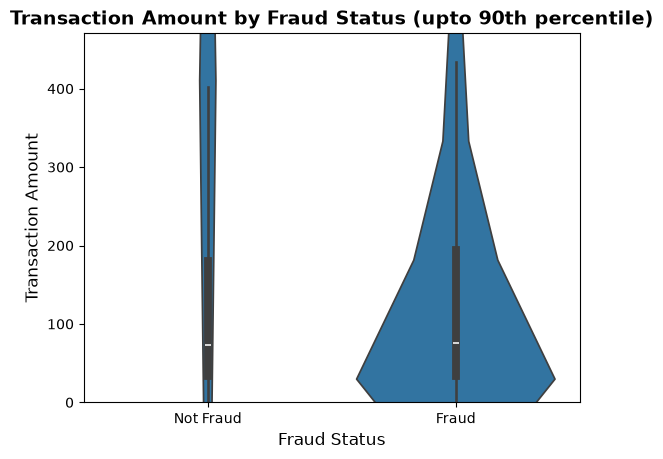

In [94]:
upper_limit = df["transaction_amount"].quantile(0.90)

sns.violinplot(
    data=df,
    x="is_fraud",
    y="transaction_amount"
)

plt.title("Transaction Amount by Fraud Status (upto 90th percentile)", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Transaction Amount", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.ylim(0, upper_limit)

plt.show()

**Observation**

- Fraudulent transactions have a **slightly higher median transaction amount** (**76.10**) compared to legitimate transactions (**72.95**).
- The average transaction amount is also higher for fraudulent transactions (**228.08**) than for legitimate transactions (**203.36**), indicating that fraudulent transactions tend to involve somewhat larger monetary values on average.
- Both fraudulent and legitimate transactions exhibit **strong right-skewed distributions**, with a small number of transactions having exceptionally large amounts.
- The standard deviation is higher for fraudulent transactions (**546.17**) than for legitimate transactions (**453.96**), suggesting greater variability in transaction amounts among fraudulent activities.
- The interquartile ranges of the two groups overlap considerably, indicating that transaction amount alone does not clearly distinguish fraudulent transactions from legitimate ones.

**Insight**: Transaction amount exhibits noticeable differences between legitimate and fraudulent transactions, with fraudulent transactions generally involving slightly higher values and greater variability. However, the substantial overlap between the two distributions suggests that transaction amount alone is unlikely to be a reliable indicator of fraud. Its effectiveness is expected to improve when analyzed alongside other customer, transaction, and security-related features.

#### Account Balance vs Fraud

Research Question: **Do fraudulent transactions tend to occur in accounts with higher or lower balances compared to legitimate transactions?**

In [95]:
df.groupby("is_fraud")["account_balance"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,16582.702147,28132.439422,100.0,3607.190,8087.67,18213.130,500000.0
1,55255.0,16791.774147,28830.016458,100.0,3637.635,8166.15,18428.205,500000.0


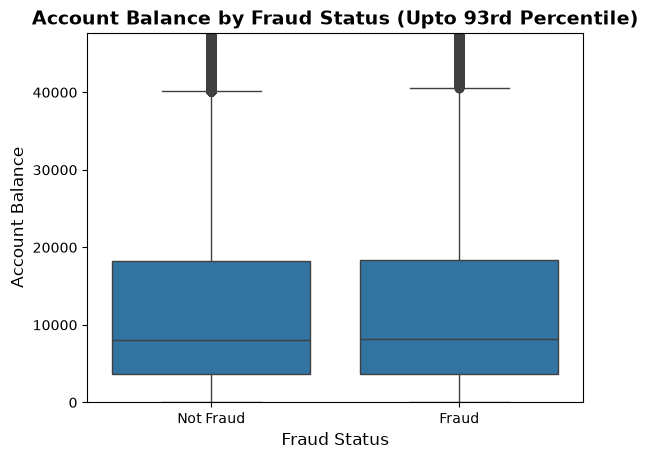

In [96]:
upper_limit = df["account_balance"].quantile(0.93)

sns.boxplot(
    data=df,
    x="is_fraud",
    y="account_balance"
)

plt.title("Account Balance by Fraud Status (Upto 93rd Percentile)", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Account Balance", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.ylim(0, upper_limit)

plt.show()

**Observation**

- Fraudulent transactions are associated with a **slightly higher median account balance** (**8,166.15**) compared to legitimate transactions (**8,087.67**).
- The average account balance is also marginally higher for fraudulent transactions (**16,791.77**) than for legitimate transactions (**16,582.70**).
- Both groups exhibit **highly right-skewed distributions**, with a small number of accounts having exceptionally large balances reaching **500,000**.
- The standard deviations are similar for both legitimate (**28,132.44**) and fraudulent (**28,830.02**) transactions, indicating comparable variability in account balances.
- The distributions of account balances for fraudulent and legitimate transactions overlap substantially, suggesting only minor differences between the two groups.

**Insight**: Account balance shows only slight differences between fraudulent and legitimate transactions, with fraudulent transactions occurring in accounts that have marginally higher balances on average. However, the considerable overlap between the two distributions indicates that account balance alone is unlikely to be a strong discriminator of fraudulent activity and should be interpreted alongside other transaction, customer, and security-related features.

### CUSTOMER FEATURES vs FRAUD

#### Customer Age vs Fraud

Research Question: **Are fraudulent transactions more common among customers of certain age groups?**

In [97]:
df.groupby("is_fraud")["customer_age"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,41.781307,13.427356,18.0,32.0,42.0,51.0,85.0
1,55255.0,41.607040,13.376234,18.0,32.0,41.0,51.0,85.0


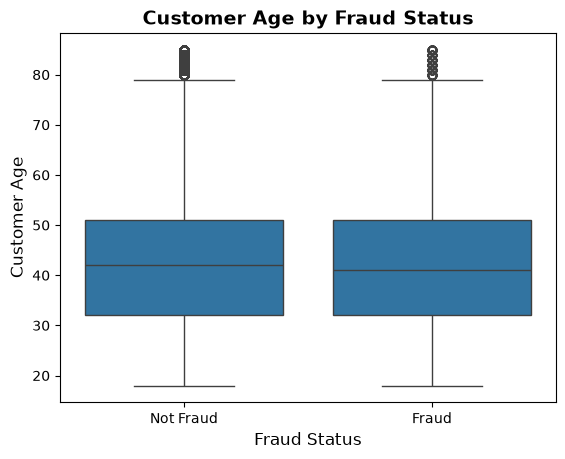

In [98]:
sns.boxplot(
    data=df,
    x="is_fraud",
    y="customer_age"
)

plt.title("Customer Age by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Customer Age", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.show()

**Observation**

- The age distributions of customers involved in legitimate and fraudulent transactions are remarkably similar.
- The median customer age is **42 years** for legitimate transactions and **41 years** for fraudulent transactions, indicating only a negligible difference between the two groups.
- The average customer age is also nearly identical, with legitimate transactions having a mean age of **41.78 years** and fraudulent transactions **41.61 years**.
- Both groups exhibit comparable variability in customer age, as reflected by similar standard deviations and identical interquartile ranges.
- The distributions overlap substantially, suggesting that fraudulent transactions occur across a broad range of customer ages rather than being concentrated within a specific age group.

**Insight**: Customer age does not exhibit a meaningful difference between legitimate and fraudulent transactions in this dataset. The strong overlap in age distributions suggests that age alone is unlikely to be a reliable indicator of fraudulent activity. Additional transaction, financial, and security-related features should be considered alongside customer age when investigating fraud patterns.

#### Credit Score vs Fraud

Research Question: **Do fraudulent transactions tend to involve customers with different credit scores than legitimate transactions?**

In [99]:
df.groupby("is_fraud")["credit_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,679.128379,78.722695,300.0,626.0,680.0,734.0,850.0
1,55255.0,677.325871,80.602137,354.0,623.0,678.0,733.0,850.0


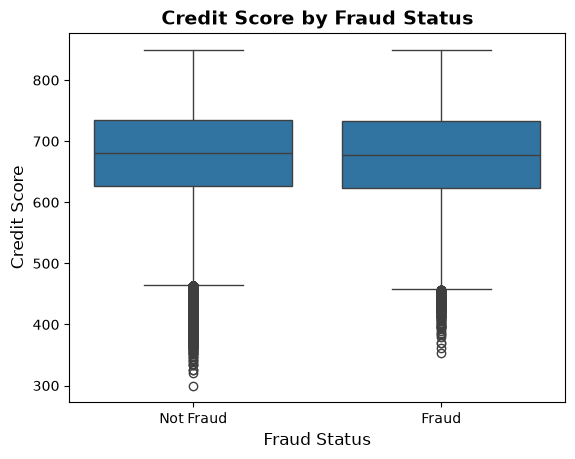

In [100]:
sns.boxplot(
    data=df,
    x="is_fraud",
    y="credit_score"
)

plt.title("Credit Score by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Credit Score", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.show()

**Observation**

- Customers involved in legitimate and fraudulent transactions have highly similar credit score distributions.
- The median credit score is **680** for legitimate transactions and **678** for fraudulent transactions, indicating only a slight difference between the two groups.
- The average credit score is marginally higher for legitimate transactions (**679.13**) than for fraudulent transactions (**677.33**).
- Both groups exhibit comparable variability in credit scores, with similar standard deviations and closely aligned interquartile ranges.
- The distributions overlap substantially, suggesting that fraudulent transactions occur across a wide range of credit scores rather than being concentrated among customers with particularly low or high credit ratings.

**Insight**: Credit score does not appear to have a strong relationship with fraudulent activity in this dataset. Although customers involved in fraudulent transactions have a marginally lower average credit score, the considerable overlap between the two distributions indicates that credit score alone is unlikely to be an effective indicator of fraud. A more meaningful understanding of fraud patterns is expected when credit score is analyzed in combination with other customer, financial, transaction, and security-related features.

#### Account Age vs Fraud

Research Question: **Do fraudulent transactions occur more frequently in newer or older customer accounts?**

In [101]:
df.groupby("is_fraud")["account_age_years"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,4.987819,4.926433,0.1,1.4,3.5,6.9,30.0
1,55255.0,4.989496,4.917702,0.1,1.4,3.5,6.9,30.0


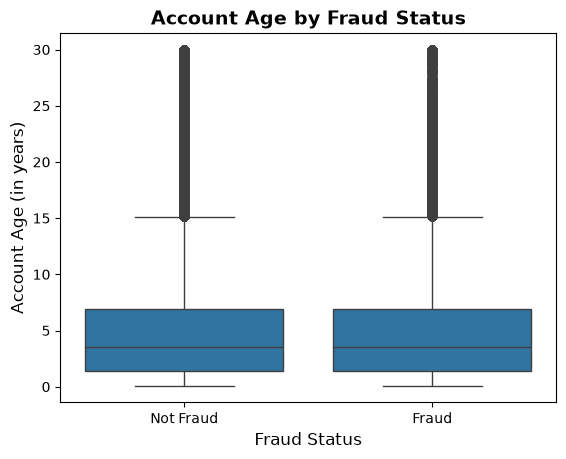

In [102]:
sns.boxplot(
    data=df,
    x="is_fraud",
    y="account_age_years"
)

plt.title("Account Age by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Account Age (in years)", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.show()

**Observation**:
- The distributions of account age are nearly identical for legitimate and fraudulent transactions.
- Both legitimate and fraudulent transactions have the same median account age of **3.5 years**, indicating no noticeable difference in the typical age of customer accounts.
- The average account age is almost identical, with legitimate transactions having a mean of **4.99 years** and fraudulent transactions **4.99 years**.
- Both groups exhibit similar variability, as reflected by nearly identical standard deviations, interquartile ranges (**1.4 to 6.9 years**), and the same account age range (**0.1 to 30 years**).
- The substantial overlap in the distributions suggests that fraudulent transactions occur across both newer and older accounts without a clear preference for either group.

**Insight**: Account age does not appear to have a meaningful relationship with fraudulent activity in this dataset. Since the distributions of legitimate and fraudulent transactions are almost indistinguishable, account age alone is unlikely to serve as an effective indicator of fraud. More informative patterns are expected to emerge when account age is analyzed together with other financial, transaction, and security-related features.

### TRANSACTION BEHAVIOUR vs FRAUD

#### Transaction Hour vs Fraud

Research Question: **Are fraudulent transactions more likely to occur during certain hours of the day?**

In [103]:
df.groupby("is_fraud")["hour_of_day"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,11.562358,6.881101,0.0,6.0,12.0,18.0,23.0
1,55255.0,10.379115,7.528845,0.0,4.0,9.0,17.0,23.0


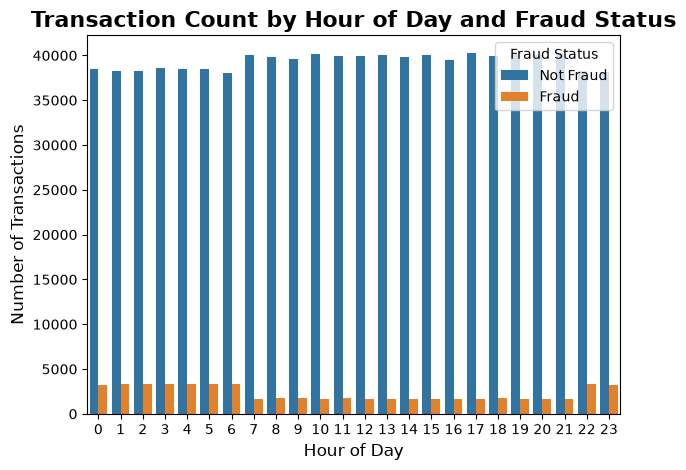

In [104]:
sns.countplot(
    data=df,
    x="hour_of_day",
    hue="is_fraud"
)

plt.title("Transaction Count by Hour of Day and Fraud Status", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Number of Transactions", fontsize=12)
plt.legend(title="Fraud Status", labels=["Not Fraud", "Fraud"])

plt.tight_layout()
plt.show()

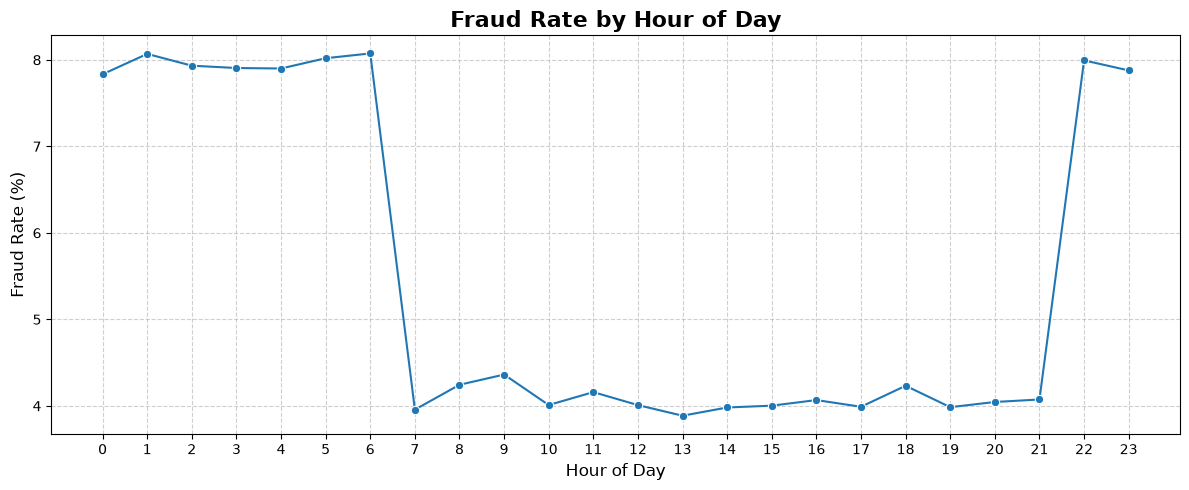

In [105]:
hourly_fraud = (
    df.groupby("hour_of_day")["is_fraud"]
      .mean()
      .mul(100)
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    x=hourly_fraud.index,
    y=hourly_fraud.values,
    marker="o"
)

plt.title("Fraud Rate by Hour of Day", fontsize=16, fontweight="bold")
plt.xlabel("Hour of Day", fontsize=12)
plt.ylabel("Fraud Rate (%)", fontsize=12)

plt.xticks(range(24))
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

**Observation**:
- Fraudulent transactions occur at an **earlier average hour of the day** (**10.38**) compared to legitimate transactions (**11.56**).
- The median transaction hour is **9:00 AM** for fraudulent transactions, whereas it is **12:00 PM** for legitimate transactions, indicating that fraudulent activity tends to occur earlier in the day.
- Fraudulent transactions exhibit a slightly **greater variability** in transaction timing, as reflected by a higher standard deviation (**7.53**) compared to legitimate transactions (**6.88**).
- Both legitimate and fraudulent transactions span the full 24-hour period (**0 to 23 hours**), indicating that fraud is not confined to a specific time window.
- Although transactions occur throughout the day, the lower average and median hours for fraudulent transactions suggest a tendency for fraud to occur relatively earlier than legitimate transactions.

**Insight**: Transaction timing appears to exhibit a modest relationship with fraudulent activity. Fraudulent transactions tend to occur earlier in the day and display slightly greater variability in timing compared to legitimate transactions. While the difference is not substantial enough to identify fraud based solely on transaction hour, temporal information may provide valuable context when combined with other transaction and customer characteristics.

#### Distance from Home vs Fraud

Research Question: **Do fraudulent transactions generally occur farther from customers' homes than legitimate transactions?**

In [106]:
df.groupby("is_fraud")["distance_from_home_km"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,20.011654,20.018400,0.0,5.7,13.9,27.7,292.1
1,55255.0,19.979719,19.891993,0.0,5.8,13.9,27.6,235.7


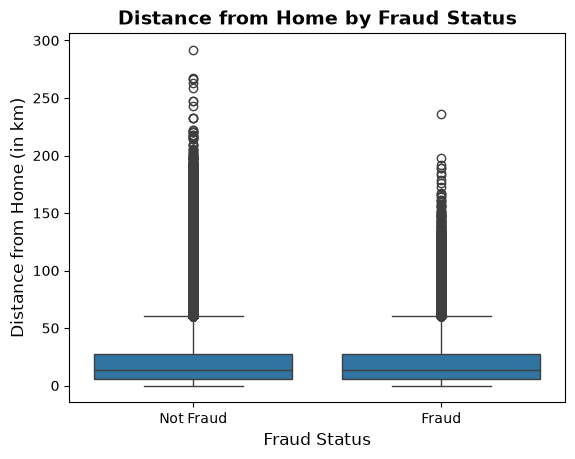

In [107]:
sns.boxplot(
    data=df,
    x="is_fraud",
    y="distance_from_home_km"
)

plt.title("Distance from Home by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Distance from Home (in km)", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.show()

**Observation**:
- The distributions of transaction distance from home are nearly identical for legitimate and fraudulent transactions.
- The median transaction distance is **13.9 km** for both legitimate and fraudulent transactions, indicating no noticeable difference in the typical transaction location.
- The average transaction distance is almost the same, with legitimate transactions averaging **20.01 km** and fraudulent transactions **19.98 km** from customers' homes.
- Both groups exhibit comparable variability, as reflected by similar standard deviations and nearly identical interquartile ranges (**5.7–27.7 km** for legitimate transactions and **5.8–27.6 km** for fraudulent transactions).
- Transactions in both groups span a wide range of distances, although legitimate transactions include slightly more extreme maximum distances (**292.1 km**) than fraudulent transactions (**235.7 km**).

**Insight**: Distance from home does not appear to have a meaningful relationship with fraudulent activity in this dataset. The almost identical distributions of legitimate and fraudulent transactions suggest that transaction distance alone is unlikely to serve as a reliable indicator of fraud. More informative patterns are likely to emerge when distance from home is analyzed alongside other transaction characteristics, such as international status, merchant category, or transaction time.

#### Time Since Last Transaction vs Fraud

Research Question: **Do fraudulent transactions occur after shorter or longer intervals than legitimate transactions?**

In [108]:
df.groupby("is_fraud")["time_since_last_txn_hrs"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,12.026801,11.997683,0.0,3.48,8.35,16.65,154.20
1,55255.0,11.558869,12.029316,0.0,3.00,7.80,16.14,137.69


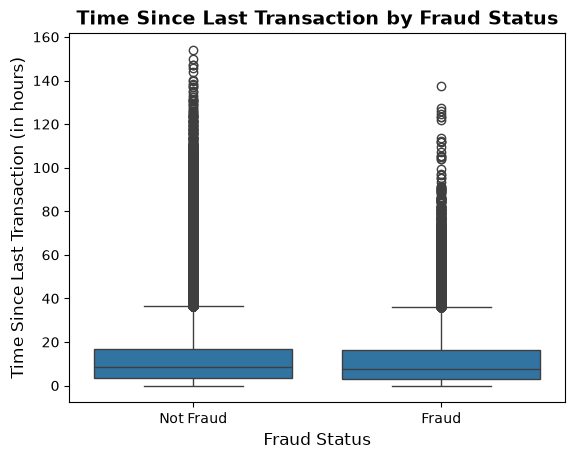

In [109]:
sns.boxplot(
    data=df,
    x="is_fraud",
    y="time_since_last_txn_hrs"
)

plt.title("Time Since Last Transaction by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Time Since Last Transaction (in hours)", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.show()

**Observation**:
- Fraudulent transactions occur after a **slightly shorter time interval** since the previous transaction compared to legitimate transactions.
- The median time since the last transaction is **7.80 hours** for fraudulent transactions, whereas it is **8.35 hours** for legitimate transactions.
- The average time since the previous transaction is also lower for fraudulent transactions (**11.56 hours**) than for legitimate transactions (**12.03 hours**).
- Both groups exhibit similar variability, as indicated by nearly identical standard deviations and comparable interquartile ranges.
- Although transactions in both groups span a wide range of time intervals, legitimate transactions include slightly longer maximum intervals (**154.20 hours**) than fraudulent transactions (**137.69 hours**).

**Insight**: Fraudulent transactions tend to occur after marginally shorter intervals than legitimate transactions, suggesting that fraud may be associated with relatively more frequent transaction activity. However, the substantial overlap between the two distributions indicates that the time since the last transaction alone is not a strong indicator of fraud. This feature is likely to provide greater value when analyzed alongside other behavioral and security-related variables.

#### Previous Transactions vs Fraud

Research Question: **Does the number of previous transactions differ between legitimate and fraudulent transactions?**

In [110]:
df.groupby("is_fraud")["num_prev_transactions"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,149.993160,12.239669,96.0,142.0,150.0,158.0,213.0
1,55255.0,150.050891,12.324612,100.0,142.0,150.0,158.0,202.0


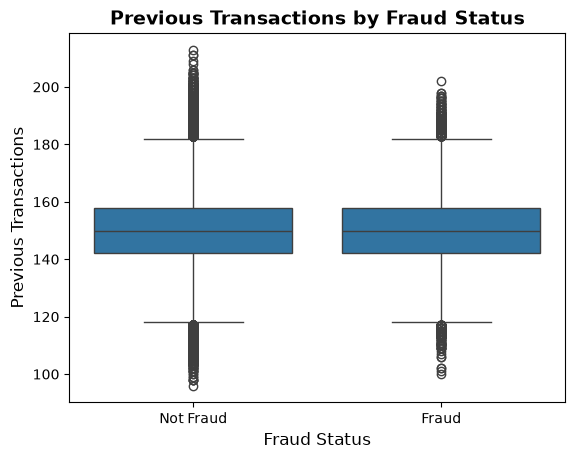

In [111]:
sns.boxplot(
    data=df,
    x="is_fraud",
    y="num_prev_transactions"
)

plt.title("Previous Transactions by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Previous Transactions", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.show()

**Observation**:
- The distributions of previous transaction counts are nearly identical for legitimate and fraudulent transactions.
- Both legitimate and fraudulent transactions have a median of **150 previous transactions**, indicating no noticeable difference in customers' historical transaction activity.
- The average number of previous transactions is almost the same, with legitimate transactions averaging **149.99** and fraudulent transactions **150.05**.
- Both groups exhibit similar variability, as reflected by nearly identical standard deviations and identical interquartile ranges (**142 to 158 transactions**).
- The distributions overlap substantially, suggesting that fraudulent transactions occur among customers with both lower and higher historical transaction counts rather than being concentrated within a specific activity level.
- 
**Insight**: The number of previous transactions does not appear to have a meaningful relationship with fraudulent activity in this dataset. Since the distributions for legitimate and fraudulent transactions are almost indistinguishable, historical transaction count alone is unlikely to be an effective indicator of fraud. This feature is expected to provide greater value when analyzed in combination with other customer, transaction, and security-related characteristics.

#### Monthly Transaction Frequency vs Fraud

Research Question: **Do fraudulent transactions tend to occur among customers with different monthly transaction frequencies than legitimate transactions?**

In [112]:
df.groupby("is_fraud")["transaction_freq_monthly"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,944745.0,19.998875,4.474417,2.0,17.0,20.0,23.0,44.0
1,55255.0,20.006968,4.467715,3.0,17.0,20.0,23.0,40.0


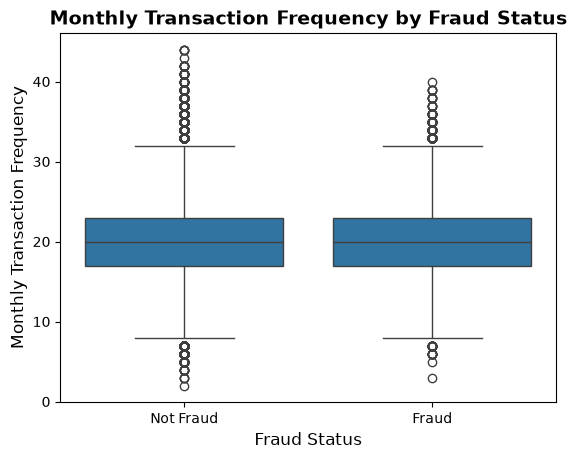

In [113]:
sns.boxplot(
    data=df,
    x="is_fraud",
    y="transaction_freq_monthly"
)

plt.title("Monthly Transaction Frequency by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Fraud Status", fontsize=12)
plt.ylabel("Monthly Transaction Frequency", fontsize=12)
plt.xticks([0, 1], ["Not Fraud", "Fraud"])

plt.show()

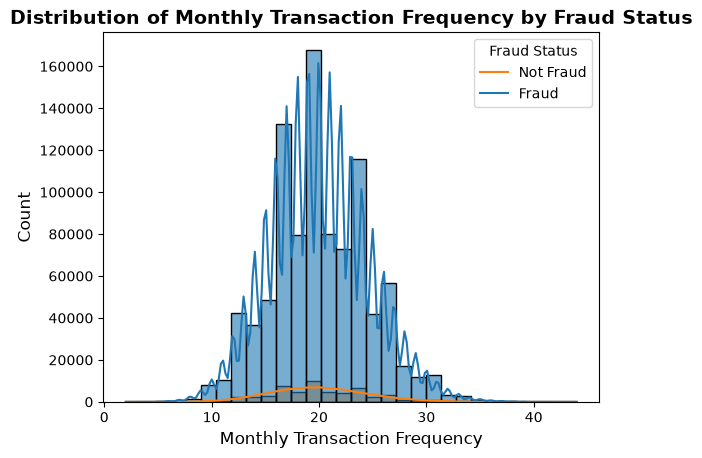

In [114]:
sns.histplot(
    data=df,
    x="transaction_freq_monthly",
    hue="is_fraud",
    bins=30,
    kde=True,
    alpha=0.6
)

plt.title("Distribution of Monthly Transaction Frequency by Fraud Status", fontsize=14, fontweight="bold")
plt.xlabel("Monthly Transaction Frequency", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.legend(["Not Fraud", "Fraud"], title="Fraud Status")

plt.show()

**Observation**:
- The distributions of monthly transaction frequency are nearly identical for legitimate and fraudulent transactions.
- Both legitimate and fraudulent transactions have a median monthly transaction frequency of **20 transactions**, indicating no noticeable difference in customers' typical transaction activity.
- The average monthly transaction frequency is almost the same, with legitimate transactions averaging **20.00 transactions** and fraudulent transactions **20.01 transactions**.
- Both groups exhibit comparable variability, as reflected by nearly identical standard deviations and identical interquartile ranges (**17 to 23 transactions**).
- The substantial overlap between the two distributions suggests that fraudulent transactions occur across customers with varying monthly transaction frequencies rather than being associated with a particular level of transaction activity.

**Insight**: Monthly transaction frequency does not appear to have a meaningful relationship with fraudulent activity in this dataset. The nearly identical distributions of legitimate and fraudulent transactions indicate that customers' average monthly transaction activity alone is unlikely to serve as an effective indicator of fraud. More informative fraud patterns are expected to emerge when this feature is analyzed alongside other behavioral, financial, and security-related variables.

### TRANSACTION CHARACTERS vs FRAUD

#### Merchant Category vs Fraud

Research Question: **Are fraudulent transactions more prevalent in specific merchant categories?**

In [115]:
df.groupby("is_fraud")["merchant_category"].value_counts()

is_fraud  merchant_category
0         Entertainment        63999
          Utilities            63752
          Electronics          63636
          Education            63621
          Clothing             63609
          Fuel                 63609
          Travel               63553
          Restaurant           63491
          Healthcare           63470
          Grocery              63392
          Gaming               63204
          Online Shopping      63202
          Jewelry              61049
          ATM Withdrawal       60587
          Crypto Exchange      60571
1         Jewelry               5821
          ATM Withdrawal        5802
          Crypto Exchange       5737
          Fuel                  3234
          Electronics           3230
          Education             3195
          Clothing              3183
          Entertainment         3151
          Healthcare            3143
          Travel                3139
          Online Shopping       3139
          

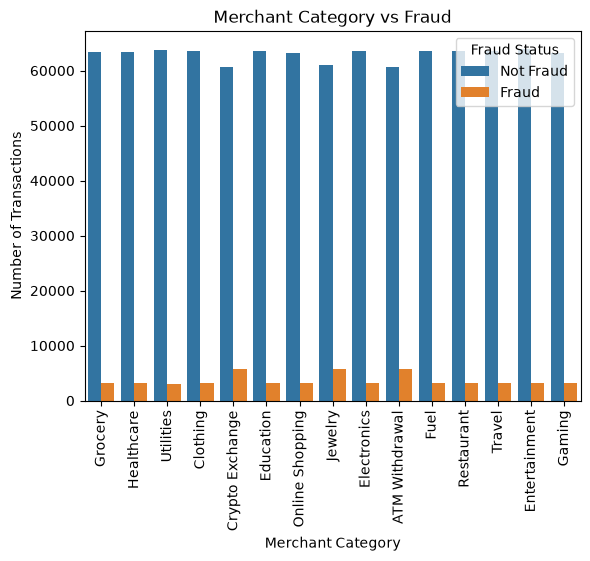

In [116]:
sns.countplot(
    data=df,
    x="merchant_category",
    hue="is_fraud"
)

plt.title("Merchant Category vs Fraud")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=90)
plt.legend(title="Fraud Status", labels=["Not Fraud", "Fraud"])

plt.show()

In [126]:
(
    df.groupby("merchant_category")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

merchant_category
ATM Withdrawal     8.739400
Jewelry            8.704950
Crypto Exchange    8.652048
Fuel               4.838203
Electronics        4.830557
Education          4.781789
Clothing           4.765541
Online Shopping    4.731614
Gaming             4.724291
Healthcare         4.718298
Restaurant         4.708231
Travel             4.706711
Entertainment      4.692480
Grocery            4.692316
Utilities          4.621415
Name: is_fraud, dtype: float64

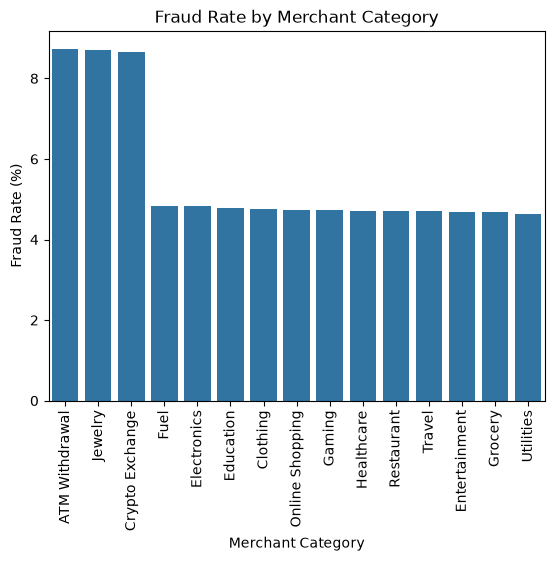

In [117]:
merchant_fraud_rate = (
    df.groupby("merchant_category")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

sns.barplot(
    x=merchant_fraud_rate.index,
    y=merchant_fraud_rate.values
)

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=90)

plt.show()

**Observation**:
- Fraud rates vary noticeably across different merchant categories, indicating that the type of merchant is associated with differing levels of fraud risk.
- **ATM Withdrawal** exhibits the highest fraud rate (**8.74%**), closely followed by **Jewelry** (**8.70%**) and **Crypto Exchange** (**8.65%**).
- Most of the remaining merchant categories have fraud rates clustered between **4.6% and 4.8%**, showing relatively similar fraud prevalence.
- **Utilities** has the lowest fraud rate (**4.62%**), followed closely by **Grocery** and **Entertainment**, indicating comparatively lower fraud occurrence in these categories.
- The fraud rate in the highest-risk merchant categories is nearly twice that of the lowest-risk categories, demonstrating a meaningful variation in fraud prevalence across merchant types.

**Insight**: Merchant category appears to be a meaningful predictor of fraudulent activity in this dataset. Transactions involving **ATM Withdrawals**, **Jewelry**, and **Crypto Exchanges** exhibit substantially higher fraud rates than other merchant categories, suggesting that these sectors may present greater opportunities or incentives for fraudulent behavior. Consequently, merchant category could serve as a valuable feature for fraud detection models and risk assessment systems.

#### Payment Method vs Fraud

Research Question: **Are fraudulent transactions more common for specific payment methods?**

In [128]:
df.groupby("payment_method")["is_fraud"].value_counts()

payment_method  is_fraud
Bank Transfer   0           141768
                1             8261
Cheque          0            27958
                1             1680
Credit Card     0           330050
                1            19568
Crypto          0            47400
                1             2758
Debit Card      0           284440
                1            16420
Mobile Payment  0           113129
                1             6568
Name: count, dtype: int64

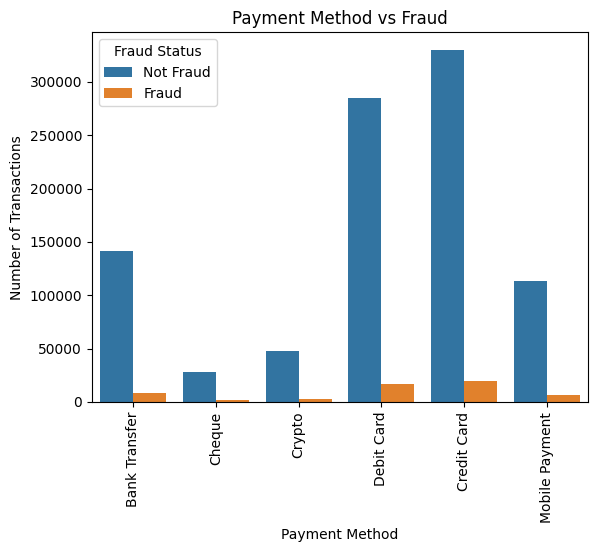

In [130]:
sns.countplot(
    data=df,
    x="payment_method",
    hue="is_fraud"
)

plt.title("Payment Method vs Fraud")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=90)
plt.legend(title="Fraud Status", labels=["Not Fraud", "Fraud"])

plt.show()

In [129]:
(
    df.groupby("payment_method")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

payment_method
Cheque            5.668399
Credit Card       5.596966
Bank Transfer     5.506269
Crypto            5.498624
Mobile Payment    5.487188
Debit Card        5.457688
Name: is_fraud, dtype: float64

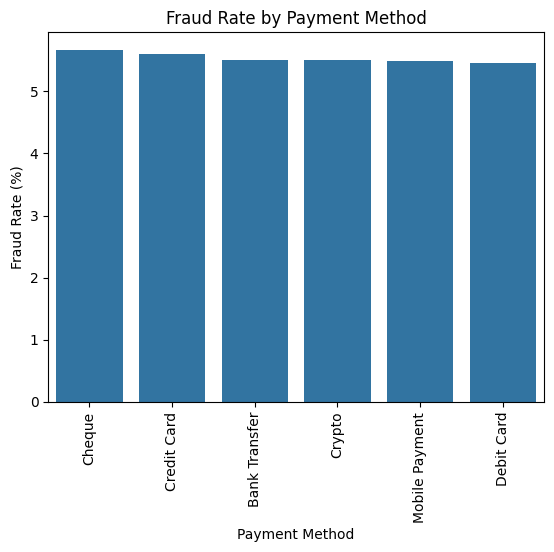

In [131]:
merchant_fraud_rate = (
    df.groupby("payment_method")["is_fraud"]
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

sns.barplot(
    x=merchant_fraud_rate.index,
    y=merchant_fraud_rate.values
)

plt.title("Fraud Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=90)

plt.show()

**Observation**:
- Fraud is observed across all payment methods, indicating that no payment method is completely immune to fraudulent activity.
- **Cheque** transactions exhibit the highest fraud rate (**5.67%**), followed closely by **Credit Card** (**5.60%**) and **Bank Transfer** (**5.51%**).
- **Debit Card** transactions have the lowest fraud rate (**5.46%**), although the difference compared to other payment methods is minimal.
- The fraud rates across all payment methods fall within a narrow range of approximately **5.46% to 5.67%**, indicating a relatively consistent level of fraud prevalence regardless of payment method.
- The small variation in fraud rates suggests that fraudulent transactions are distributed fairly uniformly across different payment methods.

**Insight**: Payment method does not appear to have a strong relationship with fraudulent activity in this dataset. Although cheque transactions exhibit the highest fraud rate, the differences across payment methods are relatively small. This indicates that payment method alone is unlikely to be a reliable indicator of fraud and is expected to provide greater predictive value when combined with other transaction, customer, and security-related features.